# Network Science - UDD

## Industria + Graph ML (cierre)

#### [*Cristian Candia-Castro Vallejos, Ph.D.*](https://crcandia.com)

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---

**Unidad 8:** comprender casos reales de redes en industria; distinguir embeddings de GNN; identificar cuándo usar —o no usar— Graph ML y cómo evaluarlo sin humo.


## Objetivos de aprendizaje

Al final de esta clase debería quedar claro que:

1. **Feature engineering topológico + ML clásico** 
2. **Embeddings de grafos** aprenden representaciones compactas de nodos. Los hay espectrales, basados en caminatas aleatorias y basados en GNN.
3. **El corazón de una GNN es message passing**: cada nodo agrega información de su vecindario de manera iterativa y diferenciable.
4. **El leakage en GNN es especialmente traicionero**: la propagación de mensajes lleva información de test a train aunque no lo veamos directamente.
5. **No siempre conviene una GNN**: hay condiciones estructurales, de datos y de recursos bajo las que un modelo más simple gana.
6. **Evaluar Graph ML** exige baselines honestos, splits correctos y métricas que importan para el problema real.

---

## 0. En la clase anterior…

La clase pasada establecimos tres pilares metodológicos que van a reaparecer hoy con más fuerza:

1. **Una red no es un dataset i.i.d.**: dependencia estructural, vecindarios compartidos, mesoestructura.
2. **Leakage en redes puede inflar brutalmente el desempeño**: un split que parece aleatorio puede ser estructuralmente deshonesto.
3. **Siempre hay que comparar contra un nulo o baseline**: detectar una estructura no basta, hay que decir si es más de lo esperable.

Hoy entonces:

> Si la estructura importa tanto, ¿qué pasa cuando le **enseñamos** a un modelo a explotar esa estructura de manera automática?

Eso es, en esencia, Graph Machine Learning.

Y vamos a ver que los mismos problemas de inferencia que estudiamos (leakage topológico, splits incorrectos, métricas sin baseline) **se amplifican** cuando el modelo tiene la capacidad de propagar información por la red.

Además, cerraremos el curso mirando cómo este toolkit se usa (y a veces se abusa) en industria.

---

## 1. Código de apoyo

Las siguientes funciones son utilitarias para los ejemplos de la clase.
Todo corre con librerías estándar: **numpy, networkx, matplotlib, sklearn**.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from collections import Counter

np.random.seed(8)

# ──────────────────────────────────────────────
# Dibujo de grafos
# ──────────────────────────────────────────────
def draw_graph(ax, G, pos=None, node_color=None, title=None,
               with_labels=False, edge_alpha=0.4, node_size=120):
    if pos is None:
        pos = nx.spring_layout(G, seed=8)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=edge_alpha, width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color,
                           node_size=node_size)
    if with_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    if title:
        ax.set_title(title, fontsize=11)
    ax.axis('off')
    return pos

# ──────────────────────────────────────────────
# Normalización de adyacencia estilo GCN (graph convolutional network)
# Kipf & Welling (2017): Ã = D̃^{-1/2} Ã D̃^{-1/2}
# donde Ã = A + I  (self-loops)
# ──────────────────────────────────────────────
def normalize_adjacency(G):
    # Convertir el grafo a una matriz de adyacencia y agregar self-loops
    # Luego normalizar usando la fórmula de Kipf & Welling
    # La función toma un grafo de NetworkX, convierte su estructura en una matriz 
    # de adyacencia, agrega self-loops (conexiones de cada nodo consigo mismo) y 
    # luego aplica la normalización propuesta por Kipf & Welling para obtener la 
    # matriz de adyacencia normalizada que se utiliza en las capas GCN.
    # Se agregan self-loops para que cada nodo también tenga en cuenta su propia información durante 
    # la actualización de características. Esto es importante para que la representación de cada nodo 
    # no dependa únicamente de sus vecinos, sino también de su propia información.
    # La normalización ayuda a estabilizar el entrenamiento de la red neuronal al 
    # evitar que las magnitudes de las características se vuelvan demasiado grandes o 
    # pequeñas durante la propagación.
    # La función devuelve la matriz de adyacencia normalizada que se puede usar como entrada para una capa GCN.
    # La matriz resultante es simétrica y tiene valores que representan la influencia relativa de los nodos vecinos 
    # en la actualización de las características del nodo central.
    A = nx.to_numpy_array(G, nodelist=sorted(G.nodes()))
    A += np.eye(len(A))                       # self-loops
    d = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
    return D_inv_sqrt @ A @ D_inv_sqrt

# ──────────────────────────────────────────────
# Capa GCN (una sola capa) implementada con numpy
# ──────────────────────────────────────────────
def gcn_layer(A_hat, H, W):
    """ReLU(Â H W)"""
    return np.maximum(0, A_hat @ H @ W)

# ──────────────────────────────────────────────
# Caminata aleatoria sobre el grafo
# ──────────────────────────────────────────────
def random_walk(G, start, length, rng):
    # Realiza una caminata aleatoria sobre el grafo G comenzando desde el nodo 'start' y con una longitud de 'length'
    # La función toma un grafo de NetworkX, un nodo de inicio, la longitud deseada de la caminata y un generador 
    # de números aleatorios para garantizar reproducibilidad.
    # En cada paso de la caminata, se selecciona aleatoriamente un vecino del nodo actual para continuar la caminata. 
    # Si el nodo actual no tiene vecinos, la caminata se detiene.
    # La función devuelve una lista de nodos que representan la secuencia de la caminata aleatoria. Esta secuencia 
    # se puede usar para construir una matriz de co-ocurrencia o para entrenar modelos de representación de nodos como DeepWalk.
    walk = [start]
    for _ in range(length - 1):
        nbrs = list(G.neighbors(walk[-1]))
        if not nbrs:
            break
        walk.append(rng.choice(nbrs))
    return walk

# ──────────────────────────────────────────────
# Co-ocurrencia por ventana (estilo DeepWalk/skip-gram)
# ──────────────────────────────────────────────
def build_cooccurrence(G, n_walks=20, walk_length=10, window=3, seed=8):
    # Crear matriz de co-ocurrencia basada en caminatas aleatorias
    # Las filas y columnas corresponden a los nodos ordenados alfabéticamente
    # El valor M[i, j] es el número de veces que el nodo j aparece dentro de la ventana del nodo i en las caminatas
    # Esto es similar a la matriz de co-ocurrencia en modelos de lenguaje, pero aplicada a nodos en un grafo
    # El parámetro 'window' define cuántos nodos antes y después del nodo central se consideran para la co-ocurrencia
    # El parámetro 'n_walks' define cuántas caminatas aleatorias se generan desde cada nodo, y 'walk_length' define 
    # la longitud de cada caminata
    # El resultado es una matriz de co-ocurrencia que puede ser utilizada para técnicas de reducción de dimensionalidad 
    # como PCA o t-SNE, o para entrenar modelos de clasificación
    # La semilla 'seed' asegura que las caminatas aleatorias sean reproducibles
    # Esta función es una implementación simplificada de la idea detrás de DeepWalk, donde se generan caminatas aleatorias
    # y se construye una matriz de co-ocurrencia para aprender representaciones de nodos
    nodes = sorted(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    n = len(nodes)
    M = np.zeros((n, n))
    rng = np.random.default_rng(seed)
    for _ in range(n_walks):
        for s in nodes:
            walk = random_walk(G, s, walk_length, rng)
            for i, u in enumerate(walk):
                for v in walk[max(0, i - window): i] + walk[i + 1: i + window + 1]:
                    M[idx[u], idx[v]] += 1
    return M

print('Librerías cargadas y funciones de apoyo definidas.')

Librerías cargadas y funciones de apoyo definidas.


## 2. El paisaje de Graph ML: ¿qué problema resolvemos?

Muchas tareas sobre redes se pueden plantear como problemas de aprendizaje supervisado o semi-supervisado:

| **Tarea** | **Unidad de predicción** | **Ejemplo** |
|-----------|--------------------------|-------------|
| Clasificación de nodos | nodo | ¿A qué categoría pertenece este usuario / paper / proteína? |
| Predicción de enlaces | par de nodos | ¿Se conectarán estos dos actores? |
| Clasificación de grafos | grafo completo | ¿Esta molécula es activa o tóxica? |
| Regresión nodal | nodo | ¿Qué nivel de actividad tendrá esta cuenta? |

Para resolver estas tareas tenemos **tres grandes estrategias**:

```
┌──────────────────────────────────────────────────────────────────────────┐
│  A) Feature engineering topológico  →  ML clásico (LR, RF, XGBoost)      │
│  B) Embeddings de grafos            →  representación compacta de nodos  │
│  C) Graph Neural Networks (GNN)     →  aprendizaje end-to-end en grafo   │
└──────────────────────────────────────────────────────────────────────────┘
```

Hay una jerarquía implícita de complejidad, pero **no de calidad garantizada**.
Un modelo de la categoría A puede superar a uno de la C si los datos son escasos, si el grafo es pequeño, o si las features topológicas ya capturan bien la señal relevante.

> **Regla práctica:** empieza por A, ve a B si A no alcanza, ve a C solo si B tampoco alcanza y tienes datos suficientes.

### ¿Por qué la complejidad no garantiza calidad?

Considera clasificar papers científicos (¿ML o Bioinformática?) usando su red de citas:

| Estrategia | F1 hipotético | Complejidad | Requiere |
|------------|--------------|-------------|----------|
| LR sobre features topológicos (grado, PageRank...) | 0.82 | baja | networkx, sklearn |
| node2vec + LR | 0.85 | media | + 30 min entrenamiento |
| GCN de 2 capas | 0.86 | alta | PyG, GPU, split correcto |

El salto A→B es moderado (0.82→0.85). El salto B→C agrega 0.01 de F1 a costa de orden de magnitud más en infraestructura y riesgo de evaluación incorrecta.

Esta jerarquía tiene apoyo empírico: Errica et al. (2020) mostraron que en muchos benchmarks de clasificación de grafos, GNN sofisticadas **no superan consistentemente** a baselines clásicos bien calibrados.

---

## 3. Estrategia A: feature engineering topológico

La estrategia más directa es extraer propiedades estructurales de cada nodo y usarlas como features en un clasificador estándar.

### Features topológicos comunes

| Feature | Qué mide | Costo computacional |
|---------|----------|--------------------|
| Grado | conectividad local | $O(m)$ |
| Clustering coefficient | densidad del vecindario | $O(m)$ típico |
| PageRank | importancia global iterativa | $O(km)$ |
| Betweenness centrality | rol de intermediación | $O(nm)$ |
| Core number | cohesión del k-core | $O(m)$ |
| Distancia media | posición global | $O(n^2)$ o aproximado |

Esta estrategia es **robusta y explicable**: cada feature tiene un nombre, una fórmula y una interpretación.

Su limitación principal es la **inducción**: si llega un nodo nuevo a la red, hay que recalcular todo.

Nota: en redes, por convención, n represneta nodos y m aristas

In [31]:
# Usaremos el Karate Club de Zachary (1977) como red de demostración.
# Es un benchmark clásico en ciencia de redes: 34 nodos, 78 aristas,
# dos facciones conocidas ("Mr. Hi" vs "Officer").
G = nx.karate_club_graph()
nodes = sorted(G.nodes())
labels = np.array([0 if G.nodes[n]['club'] == 'Mr. Hi' else 1 for n in nodes])

# ── Extraer features topológicos ──────────────────────────────────────────
degree      = np.array([G.degree(n)                       for n in nodes])
clustering  = np.array([nx.clustering(G, n)               for n in nodes])
pagerank    = np.array([nx.pagerank(G)[n]                  for n in nodes])
betweenness = np.array([nx.betweenness_centrality(G)[n]    for n in nodes])
core        = np.array([nx.core_number(G)[n]               for n in nodes])
triangles   = np.array([nx.triangles(G, n)                 for n in nodes])

# clustering y triangles se diferencian en que clustering mide la proporción de vecinos que están 
# conectados entre sí, mientras que triangles cuenta el número total de triángulos en los que participa 
# un nodo. Un nodo puede tener un alto número de triángulos pero un bajo coeficiente de clustering si 
# tiene muchos vecinos pero pocos de ellos están conectados entre sí. Por otro lado, un nodo con un 
# alto coeficiente de clustering puede tener pocos triángulos si tiene pocos vecinos, pero esos vecinos 
# están muy interconectados.
X_topo = np.column_stack([degree, clustering, pagerank, betweenness, core, triangles])
feature_names = ['degree', 'clustering', 'pagerank', 'betweenness', 'core', 'triangles']

df_topo = pd.DataFrame(X_topo, columns=feature_names)
df_topo['faccion'] = ['Mr. Hi' if l == 0 else 'Officer' for l in labels]
df_topo.head(8)

,degree,clustering,pagerank,betweenness,core,triangles,faccion
0,16.0,0.150000,0.088508,0.437635,4.0,18.0,Mr. Hi
1,9.0,0.333333,0.057415,0.053937,4.0,12.0,Mr. Hi
2,10.0,0.244444,0.062767,0.143657,4.0,11.0,Mr. Hi
3,6.0,0.666667,0.037212,0.011909,4.0,10.0,Mr. Hi
4,3.0,0.666667,0.020504,0.000631,3.0,2.0,Mr. Hi
5,4.0,0.500000,0.033810,0.029987,3.0,3.0,Mr. Hi
6,4.0,0.500000,0.031529,0.029987,3.0,3.0,Mr. Hi
7,4.0,1.000000,0.026465,0.000000,4.0,6.0,Mr. Hi


In [32]:
# ── Clasificación con Logistic Regression usando features topológicos ─────
# Nota: usamos todos los nodos para ilustrar capacidad de separación;
# la evaluación honesta requeriría un split correcto (ver Sección 8).

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_topo)

# En sklearn, LogisticRegression tiene un parámetro llamado 'C' que controla la 
# fuerza de la regularización. Por defecto, 'C' es igual a 1.0, lo que significa 
# que se aplica una regularización L2 con una fuerza estándar. Si deseas aumentar la 
# regularización, puedes disminuir el valor de 'C' (por ejemplo, C=0.1 o C=0.01). 
# Si deseas reducir la regularización, puedes aumentar el valor de 'C' (por ejemplo,
#  C=10 o C=100). En este código, no se especifica el parámetro 'C', por lo que se 
# está utilizando la regularización L2 con su valor predeterminado de 1.0.
lr = LogisticRegression(max_iter=500, random_state=8)
lr.fit(X_scaled, labels)
preds_topo = lr.predict(X_scaled)

acc_topo = accuracy_score(labels, preds_topo)
f1_topo  = f1_score(labels, preds_topo)

print(f'Accuracy con features topológicos: {acc_topo:.3f}')
print(f'F1 con features topológicos:       {f1_topo:.3f}')
print()
print('Coeficientes LR (importancia relativa):')
for feat, coef in sorted(zip(feature_names, lr.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {feat:>12s}:  {coef:+.3f}')

#Nota: La regularización L2 (o regresión Ridge) es una técnica utilizada en aprendizaje automático 
# para prevenir el sobreajuste (overfitting) penalizando los pesos grandes del modelo. Añade 
# la suma de los cuadrados de los coeficientes, multiplicada por un parámetro 
# (lambda), a la función de pérdida, forzando a los pesos a ser pequeños sin llegar necesariamente a cero.

Accuracy con features topológicos: 0.676
F1 con features topológicos:       0.718

Coeficientes LR (importancia relativa):
     triangles:  -0.987
        degree:  +0.598
      pagerank:  +0.472
          core:  -0.340
    clustering:  -0.194
   betweenness:  -0.171


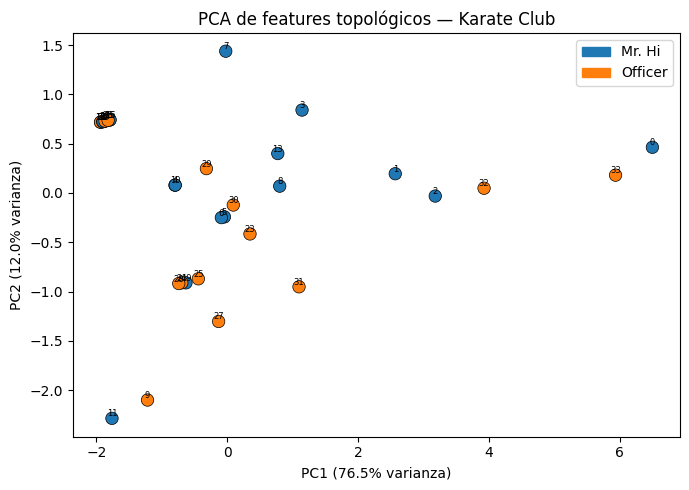

In [33]:
# ── Visualizar la separabilidad en espacio PCA ────────────────────────────
pca = PCA(n_components=2, random_state=8)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['tab:blue' if l == 0 else 'tab:orange' for l in labels]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=80, edgecolors='k', linewidths=0.5)
for i, n in enumerate(nodes):
    ax.annotate(str(n), (X_pca[i, 0], X_pca[i, 1]), fontsize=6, ha='center', va='bottom')

patch0 = mpatches.Patch(color='tab:blue', label='Mr. Hi')
patch1 = mpatches.Patch(color='tab:orange', label='Officer')
ax.legend(handles=[patch0, patch1])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('PCA de features topológicos — Karate Club')
plt.tight_layout()
plt.show()

#### Takeaway

Los features topológicos logran **67.6% de accuracy en muestra** —un resultado modesto que merece explicación.

Primero, hay que entender el contexto: el Karate Club tiene 34 nodos, y un clasificador que siempre predice la clase mayoritaria (Officer) tendría 52.9%. Lograr 67.6% con solo 6 features sin entrenar sobre etiquetas de test ya indica señal real.

Segundo, la regularización L2 de la regresión logística **impide sobreajuste** incluso en muestra: LR no memoriza los 34 puntos, busca un hiperplano generalizable. Algunos nodos en los bordes estructurales de la red (los puentes entre las dos facciones) no son separables linealmente con estas features, y eso es correcto —esos nodos son genuinamente ambiguos.

Tercero, y lo más importante: los embeddings (que veremos a continuación) dan 97% y 100% en muestra. ¿Eso los hace mejores? **No necesariamente**: los embeddings memorizan la red completa. La pregunta real es cómo rinden en nodos no vistos —y ahí es donde las features topológicas interpretables son el punto de partida.

> Antes de ir a algo más complejo, **siempre hay que saber cuánto rinde este baseline**. Si el baseline interpretable ya captura el 80% de la señal, la complejidad adicional no se justifica sola.

---

## 4. Estrategia B: embeddings de grafos

Un **embedding** es una función que mapea cada nodo a un vector de dimensión fija:

$$\phi: v \to \mathbb{R}^d$$

La intuición es que nodos **estructuralmente similares** deberían quedar **cerca** en ese espacio vectorial.
"Cercano" puede significar misma comunidad, mismo rol estructural, o misma frecuencia de co-visita en caminatas aleatorias, dependiendo del método.

Hay dos grandes familias:

### 4.1 Embeddings espectrales

Un **embedding espectral** representa cada nodo como un vector usando la información contenida en los eigenvectores de una matriz asociada al grafo. La idea central es que la geometría del embedding debe reflejar la estructura de conectividad de la red: nodos fuertemente conectados, o pertenecientes a regiones estructuralmente similares, deberían quedar cerca en el espacio vectorial.

Partimos del **Laplaciano no normalizado** del grafo, definido como $L = D - A$, donde $A$ es la matriz de adyacencia y $D$ es la matriz diagonal de grados, con $D_{ii} = k_i$.

Los eigenvectores del Laplaciano se obtienen resolviendo $L\mathbf{u}_k = \lambda_k\mathbf{u}_k$, con eigenvalores ordenados como $0 = \lambda_1 \leq \lambda_2 \leq \ldots$.

**¿Por qué esto captura estructura?** El Laplaciano identifica formas de asignar valores a los nodos que respetan la conectividad de la red. Si dos nodos están conectados o pertenecen a una misma región densa, deberían recibir valores parecidos. En cambio, los valores deberían cambiar más al cruzar zonas débilmente conectadas. Por eso, los primeros eigenvectores revelan las separaciones más gruesas de la red: comunidades, bloques o regiones estructurales que están internamente cohesionadas pero relativamente separadas entre sí.

El primer eigenvector, $\mathbf{u}_1$, es trivial: para un grafo conectado, asigna el mismo valor a todos los nodos, $\mathbf{u}_1 = \mathbf{1}/\sqrt{n}$. Por eso no sirve para distinguir posiciones estructurales.

El **vector de Fiedler**, $\mathbf{u}_2$, es el primer eigenvector no trivial y cumple un rol especial:

* Su eigenvalor asociado, $\lambda_2$, se llama **conectividad algebraica**.
* Para grafos no dirigidos, $\lambda_2 = 0$ si y solo si el grafo **no está conectado**.
* Si $\lambda_2$ es pequeño pero positivo, la red está conectada, pero tiene un **cuello de botella estructural**.
* Los valores de $\mathbf{u}_2$ pueden usarse para separar el grafo en dos regiones: nodos con valores similares tienden a estar en la misma parte de la red.

Una forma simple de particionar el grafo es dividir los nodos según el signo de $\mathbf{u}_2$: valores positivos a un grupo y valores negativos a otro. Esta idea está relacionada con la partición espectral de grafos. 

Finalmente, un embedding espectral de dimensión $d$ se construye usando los primeros $d$ eigenvectores no triviales del Laplaciano. Como el primer eigenvector $\mathbf{u}_1$ es constante y no distingue nodos, se descarta. Por eso, si queremos un embedding de dimensión $d$, usamos $\mathbf{u}2, \mathbf{u}3, \ldots, \mathbf{u}{d+1}$. Cada nodo queda representado por sus coordenadas en esos eigenvectores. Por ejemplo, el nodo $i$ se representa como $\phi(i) = (u_2(i), u_3(i), \ldots, u{d+1}(i))$.

Esta es la base de los **Laplacian eigenmaps** propuestos por Belkin & Niyogi (2003), donde el objetivo es construir una representación de baja dimensión que preserve la geometría local inducida por el grafo. En términos prácticos, estos vectores pueden usarse luego como features para clasificación, clustering o visualización de nodos.


### 4.2 Embeddings por caminatas aleatorias: DeepWalk / node2vec

La intuición aquí no parte del Laplaciano, sino de una idea más parecida al lenguaje: **dos nodos son similares si aparecen en contextos parecidos cuando recorremos la red**.

Una **caminata aleatoria** es una secuencia de nodos generada moviéndose paso a paso por las aristas del grafo. Partimos en un nodo, elegimos al azar uno de sus vecinos, luego otro vecino de ese nuevo nodo, y así sucesivamente. La intuición es simple: al caminar por la red, visitamos con mayor frecuencia nodos que están estructuralmente cerca o que pertenecen a una misma región del grafo.

**DeepWalk** (Perozzi et al., 2014) usa esta idea de forma análoga a Word2Vec. Trata cada caminata como si fuera una “frase” y cada nodo como si fuera una “palabra”. Luego aplica el modelo **skip-gram**, cuyo objetivo es aprender un vector para cada nodo que permita predecir qué otros nodos aparecen cerca de él dentro de una ventana de contexto. En simple: si dos nodos aparecen muchas veces en contextos parecidos, sus embeddings quedan cerca.


**node2vec** (Grover & Leskovec, 2016) extiende DeepWalk haciendo que las caminatas sean aleatorias, pero **sesgadas**. La caminata recuerda desde qué nodo venía y decide si conviene volver, quedarse cerca o alejarse.

Los dos parámetros principales son:

* $p$: controla la tendencia a **volver al nodo anterior**.

  * $p$ bajo → aumenta la probabilidad de volver.
  * $p$ alto → desincentiva volver inmediatamente.

* $q$: controla la tendencia a **explorar lejos o quedarse cerca**.

  * $q$ bajo → favorece alejarse del punto de partida, parecido a una exploración tipo **DFS**.
  * $q$ alto → favorece quedarse en el vecindario local, parecido a una exploración tipo **BFS**.

La combinación se interpreta así:

| Combinación        | Tipo de caminata                              | Qué tiende a capturar                                       |
| ------------------ | --------------------------------------------- | ----------------------------------------------------------- |
| $p = 1$, $q = 1$   | Caminata aleatoria no sesgada                 | Similar a DeepWalk                                          |
| $p$ alto, $q$ alto | Explora localmente, evitando volver demasiado | Comunidades / homofilia local                               |
| $p$ bajo, $q$ alto | Se queda muy cerca y puede retroceder         | Vecindarios muy locales, exploración conservadora           |
| $p$ alto, $q$ bajo | Evita volver y se aleja más rápido            | Roles estructurales similares en distintas zonas            |
| $p$ bajo, $q$ bajo | Puede volver, pero también alejarse           | Comportamiento más mixto e inestable; depende más de la red |

La intuición:

> $q$ define si la caminata se comporta más como **BFS** o **DFS**, mientras que $p$ regula cuánto se permite deshacer el paso anterior. Con $p=1$ y $q=1$, node2vec se parece mucho a DeepWalk. Con otros valores, podemos sesgar las caminatas para capturar comunidades locales o roles estructurales más globales.


En nuestro código usamos **SVD** sobre una matriz de co-ocurrencia. SVD es una técnica de reducción de dimensionalidad que descompone una matriz grande en factores de menor dimensión. En este caso, la matriz resume qué nodos aparecen juntos en las caminatas. Al factorizarla, obtenemos vectores compactos para los nodos. Esta estrategia no es exactamente Word2Vec, pero captura una lógica relacionada: transformar patrones de co-ocurrencia en embeddings de baja dimensión. Esta conexión está relacionada con la interpretación de skip-gram como factorización implícita de matrices de co-ocurrencia o PMI (Levy & Goldberg, 2014).

**Limitación compartida de 4.1 y 4.2:** estos métodos suelen ser **transductivos**: aprenden embeddings para los nodos presentes al momento del entrenamiento. Si aparece un nodo nuevo, no tiene embedding automáticamente.

> Esa limitación motiva métodos inductivos como GraphSAGE (Hamilton et al., 2017), que no aprenden sólo vectores fijos por nodo, sino una función capaz de generar embeddings para nodos nuevos a partir de sus atributos y vecindario.


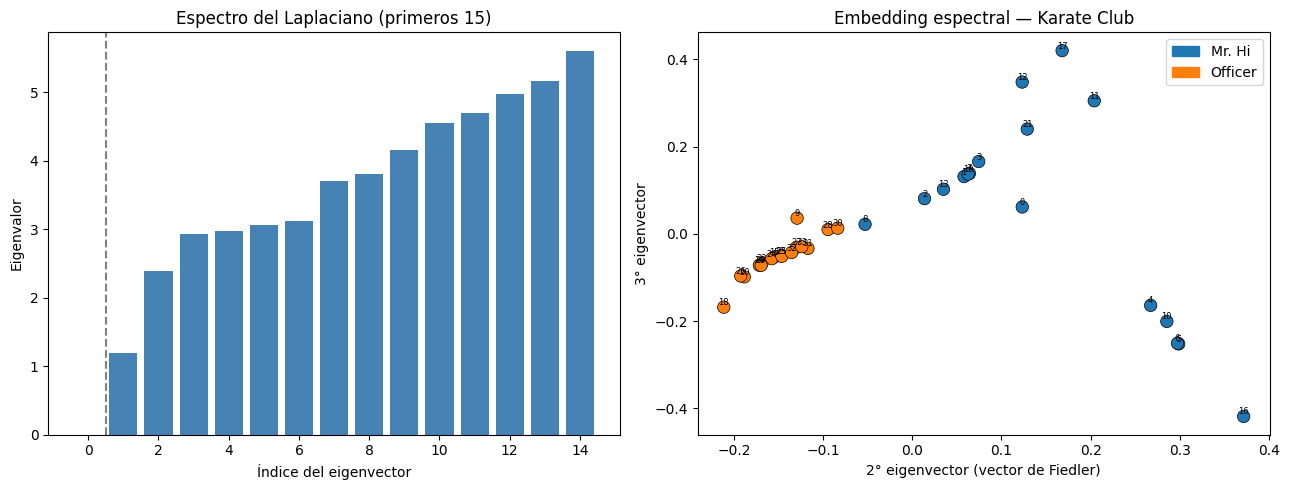

Accuracy con embedding espectral (d=4): 0.971


In [ ]:
# ── 4.1 Embedding espectral ───────────────────────────────────────────────
L = nx.laplacian_matrix(G, nodelist=nodes).toarray().astype(float)
eigenvalues, eigenvectors = np.linalg.eigh(L)

# Los d primeros eigenvectores no triviales (evitamos el trivial λ=1/\sqrt(n))
d = 4
X_spectral = eigenvectors[:, 1:d+1]  # columnas 1..d

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Espectro del Laplaciano
axes[0].bar(range(len(eigenvalues[:15])), eigenvalues[:15], color='steelblue')
axes[0].axvline(0.5, linestyle='--', color='gray')
axes[0].set_xlabel('Índice del eigenvector')
axes[0].set_ylabel('Eigenvalor')
axes[0].set_title('Espectro del Laplaciano (primeros 15)')

# Embedding en los dos primeros eigenvectores no triviales
colors = ['tab:blue' if l == 0 else 'tab:orange' for l in labels]
axes[1].scatter(X_spectral[:, 0], X_spectral[:, 1], c=colors, s=80,
                edgecolors='k', linewidths=0.5)
for i, n in enumerate(nodes):
    axes[1].annotate(str(n), (X_spectral[i, 0], X_spectral[i, 1]),
                     fontsize=6, ha='center', va='bottom')
axes[1].set_xlabel('2° eigenvector (vector de Fiedler)')
axes[1].set_ylabel('3° eigenvector')
axes[1].set_title('Embedding espectral — Karate Club')
patch0 = mpatches.Patch(color='tab:blue', label='Mr. Hi')
patch1 = mpatches.Patch(color='tab:orange', label='Officer')
axes[1].legend(handles=[patch0, patch1])

plt.tight_layout()
plt.show()

lr_spec = LogisticRegression(max_iter=500, random_state=8)
lr_spec.fit(X_spectral, labels)
acc_spec = accuracy_score(labels, lr_spec.predict(X_spectral))
print(f'Accuracy con embedding espectral (d={d}): {acc_spec:.3f}')

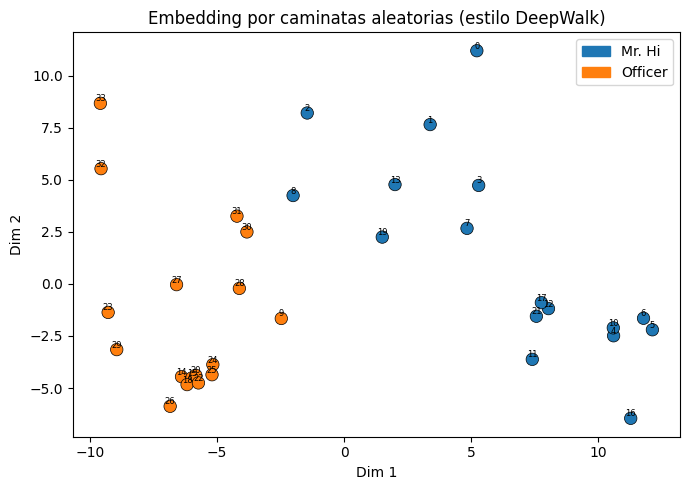

Accuracy con embedding RW (d=8, SVD): 1.000


In [19]:
# ── 4.2 Embedding por caminatas aleatorias (estilo DeepWalk simplificado) ─
# En lugar de Word2Vec completo, usamos SVD sobre la matriz de co-ocurrencia.
# La lógica es la misma: nodos que co-ocurren frecuentemente → vectores cercanos.

M = build_cooccurrence(G, n_walks=30, walk_length=12, window=3, seed=8)
M_log = np.log1p(M)  # PPMI aproximado: log(1 + conteo)

svd = TruncatedSVD(n_components=8, random_state=8)
X_rw = svd.fit_transform(M_log)

# Proyectar a 2D para visualizar
pca2 = PCA(n_components=2, random_state=8)
X_rw_2d = pca2.fit_transform(X_rw)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_rw_2d[:, 0], X_rw_2d[:, 1], c=colors, s=80,
           edgecolors='k', linewidths=0.5)
for i, n in enumerate(nodes):
    ax.annotate(str(n), (X_rw_2d[i, 0], X_rw_2d[i, 1]),
                fontsize=6, ha='center', va='bottom')
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.set_title('Embedding por caminatas aleatorias (estilo DeepWalk)')
ax.legend(handles=[patch0, patch1])
plt.tight_layout()
plt.show()

lr_rw = LogisticRegression(max_iter=500, random_state=8)
lr_rw.fit(X_rw, labels)
acc_rw = accuracy_score(labels, lr_rw.predict(X_rw))
print(f'Accuracy con embedding RW (d=8, SVD): {acc_rw:.3f}')

### Comparación de las tres estrategias en el Karate Club

| Método | Accuracy en muestra | Generaliza a nodos nuevos | Interpretable |
|--------|--------------------|-----------------------------|---------------|
| Features topológicos + LR | **67.6%** | ✓ (recalculando features) | ✓ (cada feature tiene nombre) |
| Embedding espectral (d=4) | **97.1%** | ✗ (transductivo) | Parcial (eigenvectores globales) |
| Embedding RW + SVD (d=8) | **100%** | ✗ (transductivo) | ✗ (espacio latente opaco) |

**Interpretación de los números:**

- **67.6% (topológico)**: el modelo no memoriza —usa regularización y 6 features. Hay nodos en los bordes de las facciones que no son linealmente separables con estas features. Este número es conservador y honesto.
- **97.1% (espectral)**: el Laplaciano captura la estructura de comunidad directamente. Con d=4 dimensiones el espacio espectral ya separa casi perfectamente las dos facciones.
- **100% (RW)**: SVD sobre la matriz de co-ocurrencia con d=8 puede memorizar perfectamente 34 nodos. En un grafo de 1 millón de nodos, este resultado no escalaría así.

> **La limitación compartida de los dos embeddings:** no generalizan a nodos no vistos. Si mañana un estudiante nuevo entra al karate club (nodo 34), no tiene embedding. Eso motiva las GNN, que aprenden una *función*, no un vector fijo.

---


## 5. Estrategia C: Graph Neural Networks (GNN)

### 5.1 El problema que resuelven

Los embeddings vistos antes —por ejemplo embeddings espectrales, DeepWalk o node2vec— suelen ser **transductivos**: aprenden una representación para los nodos que ya existen en un grafo fijo. Si aparece un nodo nuevo, normalmente hay que recalcular o reentrenar el embedding.

Las **Graph Neural Networks (GNN)** abordan el problema de otra manera. En vez de aprender sólo un vector fijo para cada nodo, aprenden una **función** que transforma atributos y vecindarios en embeddings.

La diferencia conceptual es importante:

> Los métodos transductivos aprenden “vectores para estos nodos”.
> Las GNN inductivas aprenden “una regla para construir vectores a partir de features y conexiones”.

Por eso, si llega un nodo nuevo con atributos y enlaces observables, una GNN inductiva puede calcular su embedding usando la función ya aprendida. Esta es la lógica central de modelos como **GraphSAGE** (Hamilton et al., 2017).

Matiz importante: una GNN no es inductiva automáticamente. Si usamos como input la matriz identidad $I_n$, cada nodo queda representado por un identificador único. Eso puede servir en un grafo fijo, como Karate Club, pero limita la generalización a nodos nuevos. Para aprendizaje inductivo real, es mejor usar atributos nodales reutilizables: edad, texto, comportamiento, features topológicas locales, variables individuales, etc.

---

### 5.2 Message passing: el corazón conceptual

El concepto central de una GNN es el **message passing**. La idea es que cada nodo actualiza su representación mirando la información que recibe de sus vecinos.

En una capa de GNN ocurren tres pasos:

1. **MESSAGE:** cada vecino envía un mensaje.
2. **AGGREGATE:** el nodo combina los mensajes recibidos.
3. **UPDATE:** el nodo actualiza su propia representación usando su estado anterior y la información agregada.

La formulación general es:

$ \mathbf{m}_{v}^{(k)} = \mathrm{AGGREGATE}^{(k)}\left(\left\{ \mathrm{MESSAGE}^{(k)}\left(\mathbf{h}_{v}^{(k-1)}, \mathbf{h}_{u}^{(k-1)}, \mathbf{e}_{uv}\right) : u \in \mathcal{N}(v) \right\}\right) $

$ \mathbf{h}_{v}^{(k)} = \mathrm{UPDATE}^{(k)}\left(\mathbf{h}_{v}^{(k-1)}, \mathbf{m}_{v}^{(k)}\right) $

Donde:

* $\mathbf{h}_v^{(k)}$ es la representación del nodo $v$ después de la capa $k$.
* $\mathbf{h}_v^{(0)}$ son los atributos iniciales del nodo.
* $\mathcal{N}(v)$ es el conjunto de vecinos de $v$.
* $\mathbf{e}_{uv}$ representa atributos de la arista, si existen.
* $\text{AGGREGATE}$ puede ser suma, promedio, máximo o atención.
* $\text{UPDATE}$ actualiza la representación del nodo combinando su estado anterior con la información agregada desde sus vecinos. Esta actualización suele tener parámetros aprendibles, por ejemplo una transformación lineal seguida de una activación

La intuición por capas es:

> Una capa permite que cada nodo incorpore información de sus vecinos directos.
> Dos capas permiten incorporar información de vecinos de vecinos.
> Después de $K$ capas, el embedding de un nodo contiene información de su vecindario hasta distancia $K$.

Esto se conoce como el **campo receptivo** del nodo. Es análogo a una CNN en imágenes: una primera capa ve patrones locales, capas más profundas combinan patrones cada vez más amplios. En grafos, “local” significa “alrededor del nodo en la red”.

---

### Ejemplo concreto en Karate Club

Supongamos que queremos actualizar la representación del nodo 1.

En la primera capa, el nodo 1 mira a sus vecinos directos. Recibe sus vectores, los combina y actualiza su representación. En palabras simples:

> “Mi nuevo embedding depende de quiénes son mis vecinos y de qué información tienen.”

En la segunda capa, el nodo 1 vuelve a mirar a sus vecinos, pero ahora esos vecinos ya incorporaron información de sus propios vecinos. Entonces el nodo 1 recibe información estructural más amplia.

> Capa 1: el nodo 1 aprende de sus vecinos directos.
> Capa 2: el nodo 1 aprende indirectamente de los vecinos de sus vecinos.
> Capa 3: el nodo 1 incorpora información desde una región aún más amplia del grafo.

Por eso una GNN no sólo mira la posición inmediata del nodo, sino que construye una representación progresivamente más contextual.

---

### Casos especiales conocidos


| Modelo        | Significado de la sigla         | Cómo agrega información     | Intuición                                                           | Cita                     |
| ------------- | ------------------------------- | --------------------------- | ------------------------------------------------------------------- | ------------------------ |
| **GCN**       | **Graph Convolutional Network** | Suma normalizada de vecinos | Promedia información local corrigiendo por grado                    | Kipf & Welling (2017)    |
| **GraphSAGE** | **Graph Sample and Aggregate**  | Media, LSTM o máximo        | Aprende agregadores inductivos para nodos nuevos                    | Hamilton et al. (2017)   |
| **GAT**       | **Graph Attention Network**     | Atención sobre vecinos      | Aprende qué vecinos pesan más                                       | Veličković et al. (2018) |
| **GIN**       | **Graph Isomorphism Network**   | Suma + MLP                  | Agregación muy expresiva, relacionada con el test Weisfeiler-Lehman | Xu et al. (2019)         |


### 5.3 GCN desde cero

La **Graph Convolutional Network (GCN)** de Kipf & Welling (2017) puede entenderse como una versión simple y eficiente del *message passing*.

La actualización de una capa es:

$H^{(l+1)} = \sigma\left(\hat{A} H^{(l)} W^{(l)}\right)$

donde:

* $H^{(l)}$ es la matriz de representaciones de los nodos en la capa $l$.
* $W^{(l)}$ es una matriz de pesos aprendibles.
* $\sigma$ es una función de activación, por ejemplo ReLU.
* $A$ es la matriz de adyacencia original del grafo.
* $\tilde{A} = A + I$ es la adyacencia con **self-loops**: cada nodo queda conectado consigo mismo.
* $\tilde{D}$ es la matriz de grados de $\tilde{A}$, es decir, los grados después de agregar los self-loops.
* $\hat{A} = \tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$ es la versión normalizada de esa adyacencia aumentada.

La operación tiene tres intuiciones simultáneas:

1. **Agregar self-loops:** cada nodo no sólo recibe información de sus vecinos, también conserva parte de su propia información.
2. **Normalizar por grado:** evita que nodos con muchos vecinos dominen excesivamente la agregación.
3. **Aprender una transformación:** $W^{(l)}$ aprende qué combinaciones de features son útiles para la tarea.

En simple:

> Primero agregamos self-loops a la red, luego normalizamos esa red aumentada por grado, y finalmente usamos esa matriz normalizada $\hat{A}$ para mezclar la información de cada nodo con la de sus vecinos.


---

### ¿Qué usamos como features iniciales $H^{(0)}$?

Si tenemos atributos nodales, usamos esos atributos. Por ejemplo, en una red escolar podríamos usar variables individuales, métricas locales, género codificado, asistencia, rendimiento, centralidades previas o cualquier feature disponible y justificable.

Si no tenemos atributos nodales, como ocurre en el ejemplo clásico de Karate Club, una opción común es usar la matriz identidad $I_{n \times n}$. En ese caso, cada nodo parte con un vector único: una posición vale 1 y todas las demás valen 0.

Esto permite que la GCN aprenda desde la estructura del grafo, pero tiene una limitación:

> Usar $I_n$ funciona bien para un grafo fijo, pero no es ideal para generalización inductiva, porque el vector inicial depende de la identidad de cada nodo.

Otra opción más inductiva es usar features estructurales locales, como grado, clustering, core number o atributos observables del nodo. Así, si aparece un nodo nuevo, podemos calcular sus features iniciales y pasarlas por la GNN ya entrenada.


In [34]:
# ── GCN desde cero con numpy ──────────────────────────────────────────────
# Demostración conceptual: 2 capas, sin entrenamiento por backprop.
# Usamos pesos aleatorios para mostrar qué hace el message passing.

rng_gcn = np.random.default_rng(42)

# Â normalizado
A_hat = normalize_adjacency(G)

# Features iniciales: one-hot de identidad (sin features reales)
n_nodes = len(nodes)
H0 = np.eye(n_nodes)  # cada nodo empieza siendo solo él mismo

# Pesos aleatorios para ilustración
d1, d2 = 8, 2        # dimensiones de capas ocultas
W1 = rng_gcn.normal(0, 0.1, (n_nodes, d1))
W2 = rng_gcn.normal(0, 0.1, (d1, d2))

# Forward pass: 2 capas de message passing
H1 = gcn_layer(A_hat, H0, W1)   # capa 1: agrega vecinos a distancia 1
H2 = gcn_layer(A_hat, H1, W2)   # capa 2: agrega vecinos a distancia 2

print('Forma de H0 (input):  ', H0.shape)
print('Forma de H1 (capa 1):', H1.shape)
print('Forma de H2 (capa 2):', H2.shape)

Forma de H0 (input):   (34, 34)
Forma de H1 (capa 1): (34, 8)
Forma de H2 (capa 2): (34, 2)


**Qué nos dicen las formas:**

- `H0` (34, 34): cada uno de los 34 nodos empieza como un vector de 34 dimensiones (su posición en la identidad).
- `H1` (34, 8): después de la primera capa, cada nodo es un vector de 8 dimensiones —la red comprimió la información del vecindario a 8 números.
- `H2` (34, 2): después de la segunda capa, cada nodo es un punto en 2D —listo para visualizar o para clasificar.

La siguiente celda muestra que con pesos **aleatorios** (sin entrenamiento) el espacio 2D no separa las clases. La GCN necesita backpropagation sobre etiquetas para que los pesos $W^{(1)}, W^{(2)}$ aprendan a orientar el espacio hacia la separación de clases.

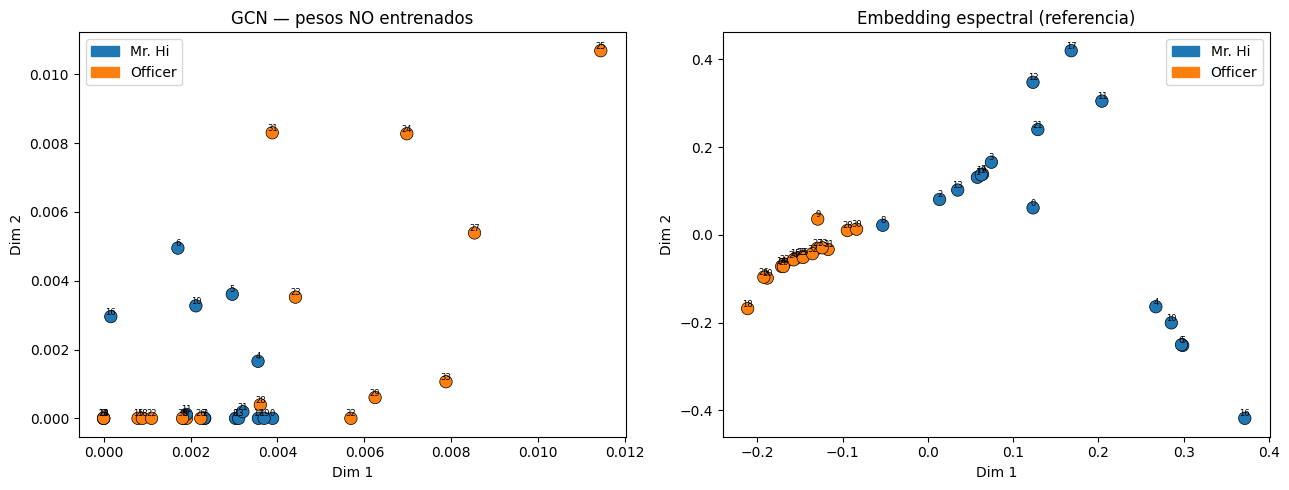

Con pesos aleatorios la GCN no separa las clases.
Necesita entrenarse (backprop sobre pérdida supervisada).


In [35]:
# ── Visualizar espacio producido por la GCN con pesos aleatorios ──
# Con pesos no entrenados, el espacio no separa las clases.
# Esto ilustra que la arquitectura sola no hace magia: necesita entrenarse.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(H2[:, 0], H2[:, 1], c=colors, s=80, edgecolors='k', linewidths=0.5)
for i, n in enumerate(nodes):
    axes[0].annotate(str(n), (H2[i, 0], H2[i, 1]), fontsize=6, ha='center', va='bottom')
axes[0].set_title('GCN — pesos NO entrenados')
axes[0].legend(handles=[patch0, patch1])
axes[0].set_xlabel('Dim 1'); axes[0].set_ylabel('Dim 2')

# Contrastar con el embedding espectral (ya «entrenado» por la matemática)
axes[1].scatter(X_spectral[:, 0], X_spectral[:, 1], c=colors, s=80,
                edgecolors='k', linewidths=0.5)
for i, n in enumerate(nodes):
    axes[1].annotate(str(n), (X_spectral[i, 0], X_spectral[i, 1]),
                     fontsize=6, ha='center', va='bottom')
axes[1].set_title('Embedding espectral (referencia)')
axes[1].legend(handles=[patch0, patch1])
axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')

plt.tight_layout()
plt.show()
print('Con pesos aleatorios la GCN no separa las clases.')
print('Necesita entrenarse (backprop sobre pérdida supervisada).')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch

# ============================================================
# 1. Preparar datos: Karate Club
# ============================================================

G = nx.karate_club_graph()
nodes = list(G.nodes())
n = len(nodes)

A = nx.to_numpy_array(G, nodelist=nodes)

# Labels: 0 = Mr. Hi, 1 = Officer
club = nx.get_node_attributes(G, "club")
y = np.array([0 if club[i] == "Mr. Hi" else 1 for i in nodes])
num_classes = 2

colors = np.array(["tab:blue" if yi == 0 else "tab:orange" for yi in y])
patch0 = Patch(color="tab:blue", label="Mr. Hi")
patch1 = Patch(color="tab:orange", label="Officer")

# Features iniciales: identidad
# Cada nodo parte con un vector one-hot.
X = np.eye(n)

# ============================================================
# 2. Construir A_hat = D_tilde^{-1/2} A_tilde D_tilde^{-1/2}
# ============================================================

A_tilde = A + np.eye(n)
degrees = A_tilde.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

# ============================================================
# 3. Split supervisado simple
# ============================================================

rng = np.random.default_rng(42)

train_idx = np.concatenate([
    rng.choice(np.where(y == 0)[0], size=4, replace=False),
    rng.choice(np.where(y == 1)[0], size=4, replace=False)
])

test_idx = np.setdiff1d(np.arange(n), train_idx)

Y = np.zeros((n, num_classes))
Y[np.arange(n), y] = 1

# ============================================================
# 4. Funciones auxiliares
# ============================================================

def relu(Z):
    return np.maximum(0, Z)

def relu_grad(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    Z_shift = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / expZ.sum(axis=1, keepdims=True)

def cross_entropy(P, Y, idx):
    eps = 1e-12
    return -np.mean(np.sum(Y[idx] * np.log(P[idx] + eps), axis=1))

def accuracy(P, y, idx):
    pred = P.argmax(axis=1)
    return np.mean(pred[idx] == y[idx])

# ============================================================
# 5. Inicializar pesos de una GCN de 2 capas
# ============================================================

input_dim = X.shape[1]
hidden_dim = 8
output_dim = num_classes

rng = np.random.default_rng(123)

W0 = rng.normal(0, 0.1, size=(input_dim, hidden_dim))
W1 = rng.normal(0, 0.1, size=(hidden_dim, output_dim))

lr = 0.05
epochs = 2000
weight_decay = 1e-4

losses = []

# ============================================================
# 6. Entrenamiento con backprop
# ============================================================

for epoch in range(epochs):

    # ----------------------------
    # Forward pass
    # ----------------------------
    M1 = A_hat @ X
    Z1 = M1 @ W0
    H1 = relu(Z1)

    M2 = A_hat @ H1
    Z2 = M2 @ W1
    P = softmax(Z2)

    loss = cross_entropy(P, Y, train_idx)
    loss += 0.5 * weight_decay * (np.sum(W0**2) + np.sum(W1**2))
    losses.append(loss)

    # ----------------------------
    # Backward pass
    # ----------------------------

    # Gradiente de la pérdida respecto a logits Z2
    dZ2 = np.zeros_like(P)
    dZ2[train_idx] = (P[train_idx] - Y[train_idx]) / len(train_idx)

    # Gradientes capa 2
    dW1 = M2.T @ dZ2 + weight_decay * W1
    dM2 = dZ2 @ W1.T

    # Como M2 = A_hat @ H1
    dH1 = A_hat.T @ dM2

    # ReLU
    dZ1 = dH1 * relu_grad(Z1)

    # Gradientes capa 1
    dW0 = M1.T @ dZ1 + weight_decay * W0

    # ----------------------------
    # Actualización de pesos
    # ----------------------------
    W0 -= lr * dW0
    W1 -= lr * dW1

    if epoch % 200 == 0 or epoch == epochs - 1:
        train_acc = accuracy(P, y, train_idx)
        test_acc = accuracy(P, y, test_idx)
        print(
            f"Epoch {epoch:4d} | "
            f"loss={loss:.4f} | "
            f"train_acc={train_acc:.2f} | "
            f"test_acc={test_acc:.2f}"
        )

# ============================================================
# 7. Forward final: embeddings aprendidos y predicciones
# ============================================================

# Primera capa GCN: mezcla features iniciales con vecinos y aplica W0
Z1 = (A_hat @ X) @ W0          # salida bruta de la primera capa

# Activación no lineal: embedding oculto aprendido
H1 = relu(Z1)                  # embedding de nodos

# Segunda capa GCN: mezcla embeddings con vecinos y aplica W1
Z2 = (A_hat @ H1) @ W1         # logits finales, un score por clase

# Convertir logits en probabilidades
P = softmax(Z2)                # probabilidades por clase

# Predicción: clase con mayor probabilidad
pred = P.argmax(axis=1)

print("\nAccuracy final train:", accuracy(P, y, train_idx))
print("Accuracy final test :", accuracy(P, y, test_idx))

Epoch    0 | loss=0.6916 | train_acc=0.62 | test_acc=0.62
Epoch  200 | loss=0.6844 | train_acc=0.88 | test_acc=0.92
Epoch  400 | loss=0.6581 | train_acc=1.00 | test_acc=0.92
Epoch  600 | loss=0.5746 | train_acc=1.00 | test_acc=0.88
Epoch  800 | loss=0.4275 | train_acc=1.00 | test_acc=0.88
Epoch 1000 | loss=0.2813 | train_acc=1.00 | test_acc=1.00
Epoch 1200 | loss=0.1737 | train_acc=1.00 | test_acc=1.00
Epoch 1400 | loss=0.1106 | train_acc=1.00 | test_acc=0.96
Epoch 1600 | loss=0.0759 | train_acc=1.00 | test_acc=0.96
Epoch 1800 | loss=0.0560 | train_acc=1.00 | test_acc=0.96
Epoch 1999 | loss=0.0438 | train_acc=1.00 | test_acc=0.96

Accuracy final train: 1.0
Accuracy final test : 0.9615384615384616


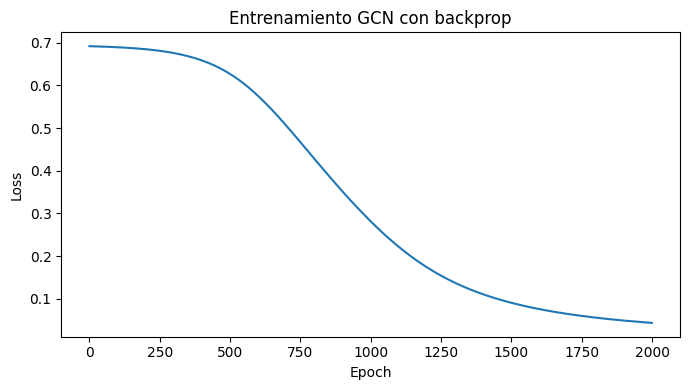

In [37]:
# ============================================================
# 8. Visualizar pérdida
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Entrenamiento GCN con backprop")
plt.tight_layout()
plt.show()

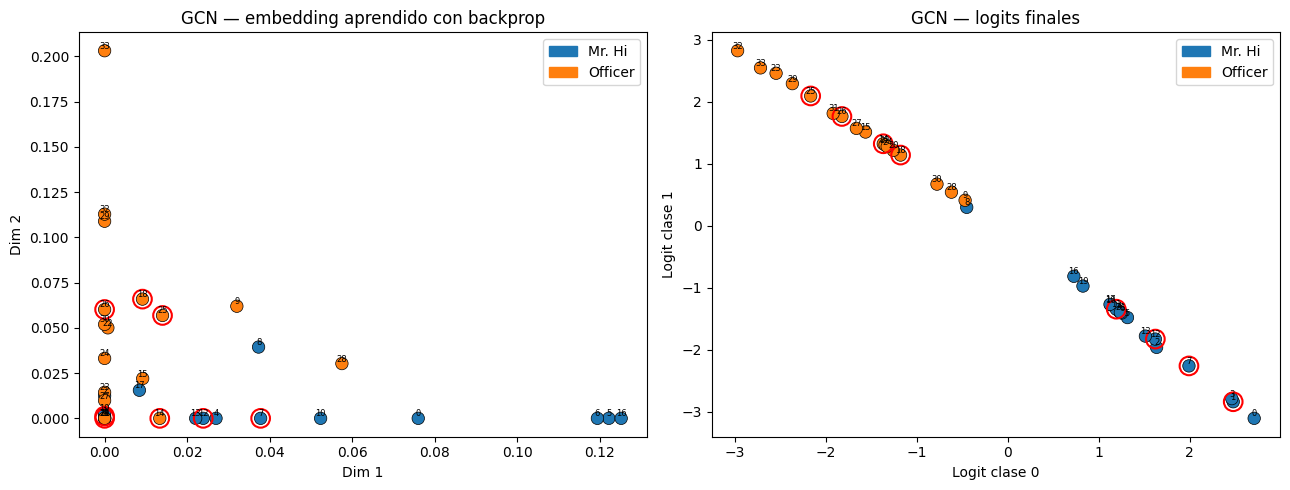

In [ ]:
# ============================================================
# 9. Visualizar embedding aprendido
# Usamos las dos primeras dimensiones de H1.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Embedding aprendido (H) por la GCN
axes[0].scatter(H1[:, 0], H1[:, 1], c=colors, s=80, edgecolors="k", linewidths=0.5)
for i, node in enumerate(nodes):
    axes[0].annotate(str(node), (H1[i, 0], H1[i, 1]), fontsize=6, ha="center", va="bottom")

axes[0].scatter(H1[train_idx, 0], H1[train_idx, 1],
                s=180, facecolors="none", edgecolors="red", linewidths=1.5,
                label="nodos usados para entrenar")

axes[0].set_title("GCN — embedding aprendido con backprop")
axes[0].set_xlabel("Dim 1")
axes[0].set_ylabel("Dim 2")
axes[0].legend(handles=[patch0, patch1])

# Logits finales (Z): espacio directamente usado para clasificar
axes[1].scatter(Z2[:, 0], Z2[:, 1], c=colors, s=80, edgecolors="k", linewidths=0.5)
for i, node in enumerate(nodes):
    axes[1].annotate(str(node), (Z2[i, 0], Z2[i, 1]), fontsize=6, ha="center", va="bottom")

axes[1].scatter(Z2[train_idx, 0], Z2[train_idx, 1],
                s=180, facecolors="none", edgecolors="red", linewidths=1.5,
                label="nodos usados para entrenar")

axes[1].set_title("GCN — logits finales")
axes[1].set_xlabel("Logit clase 0")
axes[1].set_ylabel("Logit clase 1")
axes[1].legend(handles=[patch0, patch1])

plt.tight_layout()
plt.show()

Antes del entrenamiento, la GCN sólo aplica operaciones con pesos aleatorios, por lo que no hay razón para que separe las clases. Durante el entrenamiento, backprop ajusta $W^{(0)}$ y $W^{(1)}$ para que los embeddings producidos por message passing sean útiles para predecir las etiquetas observadas.

### 5.4 ¿Qué hace realmente una GCN al agregar vecinos?

Visualicemos de forma intuitiva cómo cambia la representación de un nodo a medida que agregamos capas.

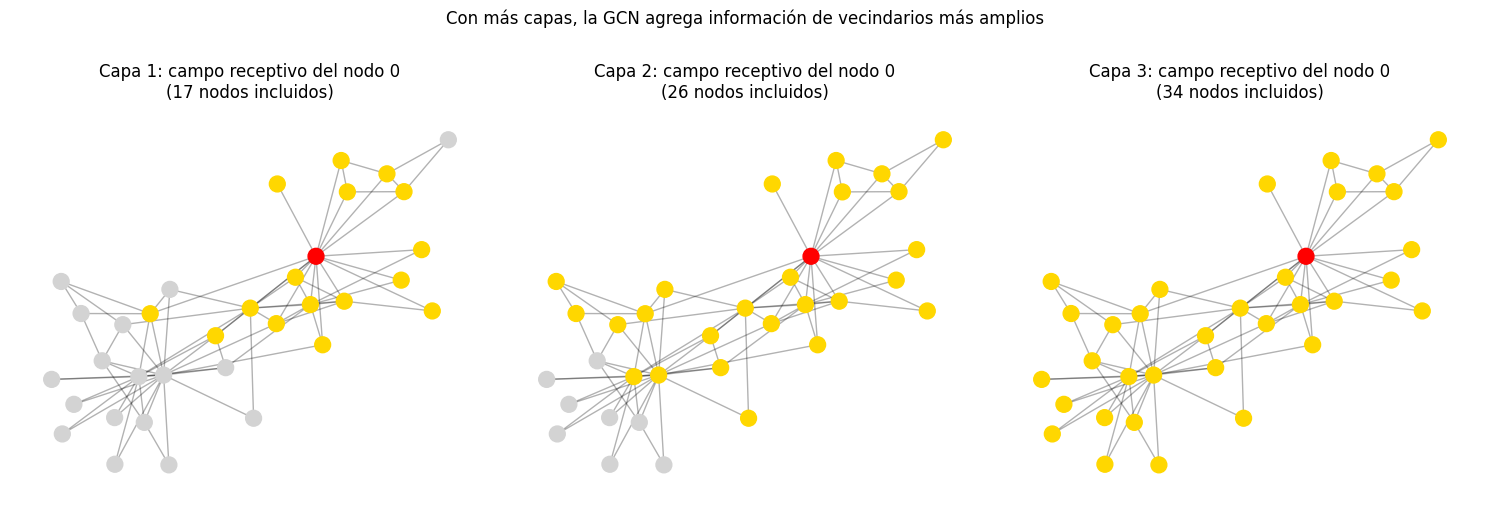

In [22]:
# ── Visualizar el campo receptivo de un nodo a distintas profundidades ────
# El nodo 0 (Mr. Hi, hub principal) tiene vecinos a distancia 1, 2, 3...
# Una GCN con K capas agrega información de nodos a distancia <= K.

target_node = 0
pos = nx.spring_layout(G, seed=8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for k, ax in enumerate(axes, start=1):
    # Nodos dentro de la esfera de radio k desde target_node
    receptive_field = set()
    receptive_field.add(target_node)
    for hop in range(k):
        frontier = set()
        for v in receptive_field:
            frontier.update(G.neighbors(v))
        receptive_field.update(frontier)

    node_colors_rf = []
    for n in sorted(G.nodes()):
        if n == target_node:
            node_colors_rf.append('red')
        elif n in receptive_field:
            node_colors_rf.append('gold')
        else:
            node_colors_rf.append('lightgray')

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors_rf, node_size=130)
    ax.set_title(f'Capa {k}: campo receptivo del nodo 0\n({len(receptive_field)} nodos incluidos)')
    ax.axis('off')

plt.suptitle('Con más capas, la GCN agrega información de vecindarios más amplios', y=1.01)
plt.tight_layout()
plt.show()

#### Takeaway: el campo receptivo crece exponencialmente

Con $K$ capas, el nodo $v$ recibe información de todos los nodos a distancia $\leq K$.

**En el Karate Club específicamente** (34 nodos, diámetro ≈ 5, mundo pequeño):

| Capas $K$ | Nodos en campo receptivo del nodo 0 | % de la red |
|-----------|-------------------------------------|-------------|
| 1 | ~17 (sí mismo + 16 vecinos directos) | 50% |
| 2 | ~30 (vecinos de vecinos incluidos) | 88% |
| 3 | 34 (toda la red) | 100% |

Con solo **3 capas**, el nodo 0 ya recibe información de todos los demás nodos.
Esto tiene dos consecuencias:

1. **Over-smoothing** (Li et al., 2018): con muchas capas, todos los nodos convergen al mismo embedding porque todos agregan la misma información global. La representación pierde discriminabilidad. En práctica, GCN de 2–3 capas supera consistentemente a GCN de 6–10 capas (Pocas capas capturan contexto local útil. Muchas capas promedian en exceso y borran las diferencias estructurales).

2. **Leakage por propagación**: si un nodo de test está en el campo receptivo de un nodo de train, sus features viajan al modelo durante el forward pass —aunque su etiqueta esté enmascarada. Este problema lo desarrollamos en detalle en la Sección 8.

> **Regla empírica:** en grafos de mundo pequeño (diámetro pequeño), 2 capas son suficientes para cubrir casi toda la red. Más capas no agregan información nueva, solo ruido y over-smoothing.

---

## 6. Casos reales: Graph ML en industria

### 6.1 Recomendación a escala: PinSage (Pinterest)

**El problema:** Pinterest tiene ~2000 millones de items (pines) que los usuarios guardan en tableros.  
El grafo bipartito usuario–pin tiene ~3000 millones de aristas y no cabe en una sola GPU.

**La solución:** Ying et al. (2018) desarrollaron **PinSage**, una GCN inductiva con:

- **Mini-batch training**: en vez de cargar el grafo completo, muestrea vecindarios.
- **Curriculum learning**: empieza con ejemplos fáciles, incrementa dificultad.
- **Embeddings persistidos**: se calculan offline y se sirven en producción.

**Resultado:** +25% en engagement vs baseline de recomendación previo (embeddings sin grafo).

**Por qué el grafo importa aquí:** dos pines guardados por los mismos usuarios tienden a ser temáticamente similares —eso es señal estructural que el grafo bipartito captura y que features de imagen sola no alcanzan.

---

### 6.2 Detección de fraude financiero

**El problema:** transacciones fraudulentas representan < 0.1% del total —desbalance extremo— pero forman patrones relacionales específicos (anillos de fraude, mulas de dinero, cuentas coordinadas).

**El dataset Elliptic** (Weber et al., 2019): grafo de 203K transacciones Bitcoin y 234K aristas (flujo de monedas), con etiquetas lícito/ilícito para ~21% de los nodos.  
Es el benchmark público más citado para detección de fraude en cripto.

**Resultado relevante:** EvolveGCN (Pareja et al., 2020) —GNN temporal— supera a Random Forest en F1 en clases minoritarias porque captura **secuencias de transacciones coordinadas** que los features tabulares no ven.

**Caveat:** el split temporal es crítico; un split aleatorio infla brutalmente el F1 porque mezcla pasado y futuro en la misma red (exactamente lo que vimos en Clase 7).

https://ojs.aaai.org/index.php/AAAI/article/view/5984

---

### 6.3 Drug discovery: GNN como oráculo molecular

**El problema:** una molécula es un grafo (átomos = nodos, enlaces = aristas).  
Predecir si activa o inhibe una proteína es una tarea de **clasificación de grafos**.

**Resultado landmark:** Stokes et al. (2020) entrenaron una GNN sobre ~2500 moléculas aprobadas para predecir actividad antibacteriana y escanearon una librería de 107M de compuestos.  
Identificaron **Halicin**, que resultó activa contra bacterias resistentes a múltiples fármacos —su estructura no se parece a ningún antibiótico conocido.

**Por qué aquí sí tiene sentido una GNN:** las moléculas son grafos sin un orden canónico de átomos; los features de cada átomo dependen de su entorno local (vecinos, tipos de enlace); message passing captura esa dependencia de forma natural.

https://www.cell.com/cell/fulltext/S0092-8674%2820%2930102-1

---

### 6.4 Knowledge graphs: Google, Microsoft, Amazon

**El problema:** un knowledge graph es un grafo heterogéneo donde nodos son entidades (personas, lugares, conceptos) y aristas son relaciones tipadas ("trabaja en", "es capital de", "fue creado por").

**Aplicaciones reales:**
- **Google Knowledge Graph**: desde 2012, ~500 mil millones de hechos, alimenta el Knowledge Panel en búsquedas.
- **Microsoft Academic Graph** → **Open Academic Graph**: conecta papers, autores, venues para recomendación e inferencia de tendencias.
- **Amazon Product Graph**: relaciones entre productos para recomendación y verificación de catálogo.

**Métodos comunes:** TransE (Bordes et al., 2013), DistMult, RotatE, para link prediction en KG; GNN heterogéneas para clasificación de entidades.

---

### Resumen de casos

| Aplicación | Tipo de grafo | Tarea | Método | Ganancia sobre baseline |
|------------|---------------|-------|--------|-------------------------|
| Pinterest PinSage | bipartito, 3B aristas | ranking de items | GCN inductiva | +25% engagement |
| Elliptic Bitcoin | temporal dirigido | clasificación nodal | EvolveGCN | +F1 en clase minoritaria |
| Drug discovery | molecular | clasificación de grafos | GNN + screening | descubrimiento de Halicin |
| Knowledge graphs | heterogéneo | link prediction | TransE / GNN | completación de KG |

> **Patrón común:** en todos los casos el grafo captura **dependencias que los features tabulares no alcanzan**. Si esa dependencia estructural no existe o no aporta señal, la GNN no agrega valor.

---

## 7. «Graph ML mínimo»: el principio de parsimonia

Antes de desplegar una GNN, hay un camino más corto que frecuentemente da el 80–90% de los beneficios:

```
Paso 1 ──► Features topológicos + ML clásico (LR, RF, XGBoost)
              ↓ ¿supera baseline simple?
             SÍ ──► reporta y explica
              NO
              ↓
Paso 2 ──► Embeddings (espectral, node2vec, LINE)
              ↓ ¿agrega señal?
             SÍ ──► reporta
              NO
              ↓
Paso 3 ──► GNN (GCN, GraphSAGE, GAT)
              ↓ ¿la complejidad extra se justifica?
             SÍ ──► GNN con evaluación honesta
              NO ──► el grafo quizás no aporta señal suficiente
```

### ¿Por qué no ir directo al paso 3?

1. **Datos insuficientes:** GNN son hambrientas de datos etiquetados. Con pocos nodos/grafos, sobreajustan.
2. **Interpretabilidad:** features topológicos son explicables; GNN son cajas negras.
3. **Infraestructura:** GNN requieren PyTorch/TensorFlow, GPU, pipelines de batch; features topológicos corren en pandas.
4. **Errica et al. (2020):** en 10 de 14 benchmarks de clasificación de grafos, GNN sofisticadas no superaron estadísticamente a un Weisfeiler-Lehman kernel o a un baseline de histograma de grados bien calibrado. Concretamente muestran que, bajo una comparación experimental más justa para clasificación de grafos, varias GNN modernas no superan de forma consistente a baselines clásicos bien calibrados. Esto es importante porque algunos baselines “simples” ya capturan mucha estructura. Un histograma de grados, por ejemplo, representa cada grafo contando cuántos nodos tienen grado 0, grado 1, grado 2, etc.; aunque parece básico, puede ser muy informativo si las clases difieren en densidad, tamaño o heterogeneidad de conectividad. El Weisfeiler–Lehman graph kernel es un baseline más sofisticado: compara grafos mediante un procedimiento iterativo de “re-etiquetado” de nodos, donde cada nodo actualiza su etiqueta según las etiquetas de sus vecinos. Después de varias iteraciones, cada grafo queda representado por los patrones de etiquetas que aparecen en él, y dos grafos son considerados similares si comparten muchos de esos patrones estructurales. La lección metodológica es que: **antes de atribuir una mejora a una arquitectura neuronal, hay que comparar contra baselines estructurales fuertes, bien ajustados y evaluados bajo el mismo protocolo.**

> **La complejidad del modelo debe estar justificada por la tarea, no por la moda.**

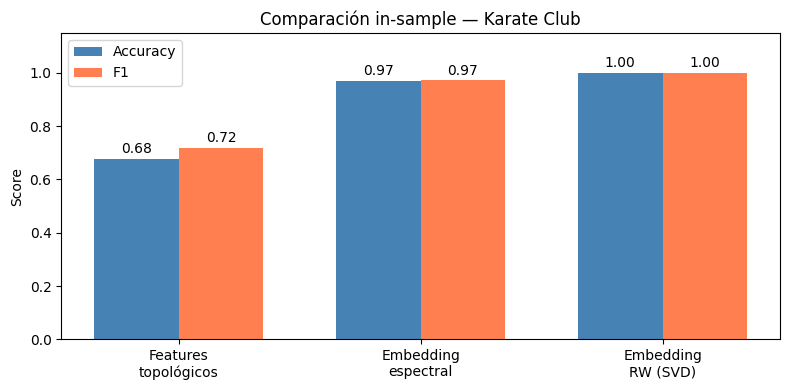

Recordatorio: todas estas métricas son in-sample (train == test).
Sirven para comparar capacidad representacional, no para reportar desempeño real.


In [26]:
# ── Comparación de los tres enfoques en el mismo dataset ─────────────────
# Nota: esta comparación in-sample ilustra la capacidad de representación.
# Una evaluación honesta requiere splits fuera de muestra (ver Sección 9).

approaches = {
    'Features\ntopológicos': (X_scaled, 'tab:blue'),
    'Embedding\nespectral': (X_spectral, 'tab:orange'),
    'Embedding\nRW (SVD)': (X_rw, 'tab:green'),
}

accs, f1s = [], []
labels_list = []

for name, (X, _) in approaches.items():
    clf = LogisticRegression(max_iter=1000, random_state=8, C=1.0)
    clf.fit(X, labels)
    pred = clf.predict(X)
    accs.append(accuracy_score(labels, pred))
    f1s.append(f1_score(labels, pred))
    labels_list.append(name)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels_list))
w = 0.35
b1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, f1s, w, label='F1', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Comparación in-sample — Karate Club')
ax.legend()
ax.bar_label(b1, fmt='%.2f', padding=2)
ax.bar_label(b2, fmt='%.2f', padding=2)
plt.tight_layout()
plt.show()

print('Recordatorio: todas estas métricas son in-sample (train == test).')
print('Sirven para comparar capacidad representacional, no para reportar desempeño real.')

## 8. Leakage en GNN: por qué es más grave que en ML clásico

En la clase anterior vimos que el leakage en redes puede venir de:

- features calculadas sobre el grafo completo (incluye test)
- nodos de train y test que comparten vecinos o comunidad
- splits temporales incorrectos

En GNN, estos problemas se **amplifican** por la propagación de mensajes.

### 8.1 El problema de la explosión de vecindarios (*neighbor explosion*)

En el setting **transductivo** (el más común: entrenamos y evaluamos en el mismo grafo), las capas de message passing propagan información a través de toda la red.

Aunque el nodo $v$ esté en el conjunto de test, sus features viajan a los nodos de train durante el forward pass, porque $v$ es vecino de algún nodo de train.

**Distinción crítica que se confunde frecuentemente:**

> El modelo **nunca** ve las *etiquetas* de los nodos de test —esas permanecen enmascaradas en la función de pérdida.
> Lo que viaja son los *features* de los nodos de test, a través de las capas de propagación.

¿Por qué importa esto? En redes con features nodales ricos (texto, imágenes, atributos demográficos), las representaciones aprendidas ya están "calibradas" con la información de los nodos de test antes de evaluarlos. El modelo no está siendo evaluado sobre ejemplos verdaderamente no vistos.

**Ejemplo concreto:** supón que el nodo 25 está en test y el nodo 20 está en train.
- En una GCN de 1 capa, si 20 y 25 son vecinos, el embedding de entrenamiento de 20 ya incorpora los features de 25.
- El modelo aprende a usar esa información de 25 para predecir la etiqueta de 20.
- Cuando luego predecimos 25 usando su propio embedding, ese embedding incluye información de 20 que el modelo ya conoce bien.
- El ciclo crea una dependencia que infla el accuracy de test.

### 8.2 Cuantificar el solapamiento de vecindarios

Shchur et al. (2018) mostraron que en los benchmarks estándar de GNN (Cora, Citeseer, Pubmed), el solapamiento de vecindarios entre train y test es tan alto que el modelo puede aprovechar información de test indirectamente.

La siguiente visualización mide ese solapamiento en un split aleatorio del Karate Club.

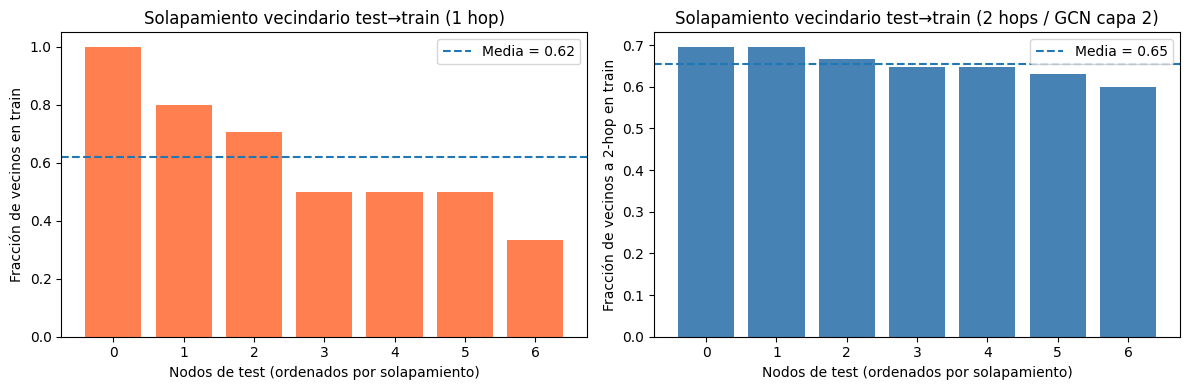

Solapamiento medio 1-hop: 0.62
Solapamiento medio 2-hop: 0.65

Interpretación: una GCN de 2 capas ve, para cada nodo de test,
en promedio el 65% de sus vecinos a 2 hops que están en train.
Esa información fluye hacia el modelo durante el forward pass.


In [11]:
# ── Solapamiento de vecindarios en un split aleatorio ─────────────────────
# Mostramos qué fracción de los vecinos de los nodos de test
# también están en train. Cuanto más alto, más leakage potencial.

G_demo = nx.karate_club_graph()
nodes_all = list(G_demo.nodes())
rng_split = np.random.default_rng(7)
rng_split.shuffle(nodes_all)

# Split aleatorio 60/20/20
n = len(nodes_all)
train_nodes = set(nodes_all[:int(0.6*n)])
val_nodes   = set(nodes_all[int(0.6*n):int(0.8*n)])
test_nodes  = set(nodes_all[int(0.8*n):])

# Para cada nodo de test: ¿cuántos de sus vecinos están en train?
overlap_counts = []
total_neighbors = []
for v in test_nodes:
    nbrs = set(G_demo.neighbors(v))
    in_train = nbrs & train_nodes
    overlap_counts.append(len(in_train))
    total_neighbors.append(len(nbrs))

overlap_frac = np.array(overlap_counts) / np.maximum(np.array(total_neighbors), 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(test_nodes)), sorted(overlap_frac, reverse=True), color='coral')
axes[0].axhline(overlap_frac.mean(), linestyle='--', label=f'Media = {overlap_frac.mean():.2f}')
axes[0].set_xlabel('Nodos de test (ordenados por solapamiento)')
axes[0].set_ylabel('Fracción de vecinos en train')
axes[0].set_title('Solapamiento vecindario test→train (1 hop)')
axes[0].legend()

# Solapamiento a 2 hops
overlap_2hop = []
for v in test_nodes:
    nbrs_2hop = set()
    for u in G_demo.neighbors(v):
        nbrs_2hop.update(G_demo.neighbors(u))
    nbrs_2hop.discard(v)
    overlap_2hop.append(len(nbrs_2hop & train_nodes) / max(len(nbrs_2hop), 1))

axes[1].bar(range(len(test_nodes)), sorted(overlap_2hop, reverse=True), color='steelblue')
axes[1].axhline(np.mean(overlap_2hop), linestyle='--',
                label=f'Media = {np.mean(overlap_2hop):.2f}')
axes[1].set_xlabel('Nodos de test (ordenados por solapamiento)')
axes[1].set_ylabel('Fracción de vecinos a 2-hop en train')
axes[1].set_title('Solapamiento vecindario test→train (2 hops / GCN capa 2)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Solapamiento medio 1-hop: {overlap_frac.mean():.2f}')
print(f'Solapamiento medio 2-hop: {np.mean(overlap_2hop):.2f}')
print()
print('Interpretación: una GCN de 2 capas ve, para cada nodo de test,')
print(f'en promedio el {np.mean(overlap_2hop):.0%} de sus vecinos a 2 hops que están en train.')
print('Esa información fluye hacia el modelo durante el forward pass.')

### 8.3 La tabla de Shchur et al. (2018): lo que encontraron

Shchur et al. (2018) replicaron varios papers de GNN variando solo la **semilla aleatoria del split** —manteniendo arquitectura, hiperparámetros y datos iguales. Sus hallazgos principales:

1. **La varianza por semilla era tan grande como la diferencia entre modelos.**
   Ejemplo: el modelo X reportaba 83.0% en el split estándar de Cora, pero con otra semilla caía a 78.0%. El modelo Y —"inferior" según el paper— subía a 84.5% con esa misma semilla. El ranking se **invertía** al cambiar la semilla.

2. **Los benchmarks estándar tienen splits diminutos.** Cora usa 20 nodos por clase en entrenamiento sobre una red de 2700 nodos (~1.5% del total). Con tan poco train, la varianza es estructuralmente alta.

3. **Hiperparámetros ajustados sobre el set de test (implícitamente).** En varios papers de la época, el early stopping y la selección de modelo usaban el test set en lugar de validación —inflando los resultados.

4. **Algunos modelos reportados como SOTA en el split estándar quedaban debajo de una GCN básica con splits alternativos.**

> **Implicación práctica:** si publicas un resultado con una sola semilla sobre Cora/Citeseer/Pubmed, no estás haciendo una comparación válida. Usa OGB (Open Graph Benchmark) y reporta media ± desviación estándar sobre ≥10 semillas.

### 8.4 Leakage por inclusión de aristas objetivo (*target-link leakage*)

En **link prediction**, hay una forma adicional de leakage que Huang et al. (2023) sistematizan:

> Si durante el message passing se incluyen las aristas que se quieren predecir (en vez de removerlas del grafo de entrada), el modelo recibe directamente la señal que debe aprender.

**Por qué pasa:** en una implementación estándar de GNN para link prediction, el grafo de entrada en evaluación puede incluir la arista (u, v) que queremos predecir. Cuando se hace message passing, el embedding de u ya recibe información de v (y viceversa) antes de que se calcule la probabilidad de la arista. La tarea se trivializa.

**En muchas implementaciones de referencia (incluyendo algunas de PyTorch Geometric) este error ocurrió silenciosamente** hasta que Huang et al. (2023) lo documentaron sistemáticamente. Al corregirlo, el ranking de modelos cambiaba significativamente.

---

## 9. Cuándo NO usar Graph ML

La pregunta más valiosa antes de desplegar Graph ML no es «¿cómo lo implemento?» sino «¿realmente necesito esto?».

### 9.1 Condiciones donde Graph ML (especialmente GNN) no suele aportar

| Condición | Por qué el grafo no ayuda |
|-----------|---------------------------|
| La red es muy dispersa / no conectada | no hay suficiente estructura para propagar |
| Los features nodales ya capturan toda la señal | el vecindario no agrega información |
| **Heterofilia alta** (nodos conectados tienden a ser *distintos*) | message passing promedia features y destruye la señal |
| Pocos nodos etiquetados | GNN sobreajustan; embeddings o features topológicos generalizan mejor |
| El grafo cambia rápidamente | los embeddings estáticos quedan desactualizados |
| Sin infraestructura GPU/ML | costo operacional supera el beneficio |

### 9.2 El caso de la heterofilia: cuando message passing hace daño

**Homofilia** de aristas: fracción de aristas que conectan nodos de la misma clase.

$$h = \frac{|\{(u,v) \in E : \text{clase}(u) = \text{clase}(v)\}|}{|E|}$$

- $h \approx 1$: red altamente homofílica (redes sociales, coautoría, citas académicas)
- $h \approx 0.5$: asortatividad neutra (conexiones aleatorias entre clases)
- $h \approx 0$: red altamente heterofílica (redes de depredación, bipartitas, oposición)

El mensaje de una GCN es: **agrega los features de tus vecinos**.
Eso funciona bien en redes homofílicas porque los vecinos son de tu misma clase.

Pero en redes con heterofilia ($h$ bajo), los vecinos son sistemáticamente de clases distintas.
**Promediar sus features introduce ruido** que hace que todos los nodos parezcan similares —exactamente lo contrario de lo que necesita un clasificador.

Lim et al. (2021) muestran que en datasets con heterofilia alta, GCN estándar queda **por debajo** de un perceptrón multicapa que ni siquiera usa la red.

Alta homofilia (p_in=0.4, p_out=0.02)         | homofilia=0.97 | GCN(voto)=1.00 | Logistic R(grado)=0.62
Homofilia media (p_in=0.2, p_out=0.1)         | homofilia=0.59 | GCN(voto)=0.68 | Logistic R(grado)=0.45
Heterofilia (p_in=0.02, p_out=0.3)            | homofilia=0.05 | GCN(voto)=0.00 | Logistic R(grado)=0.47


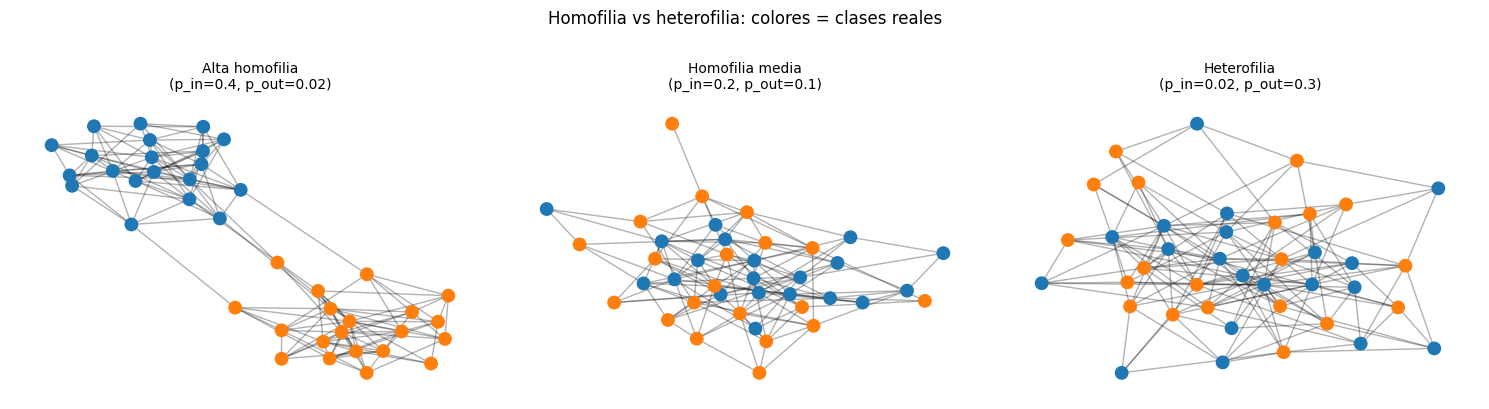

In [28]:
# ── Demostración: homofilia alta vs baja y cómo afecta a message passing ──

def make_sbm(p_in, p_out, n_per_block=20, seed=8):
    G = nx.stochastic_block_model(
        [n_per_block, n_per_block],
        [[p_in, p_out], [p_out, p_in]],
        seed=seed
    )
    labels = np.array([0]*n_per_block + [1]*n_per_block)
    return G, labels

def edge_homophily(G, labels):
    same = sum(1 for u, v in G.edges() if labels[u] == labels[v])
    return same / G.number_of_edges() if G.number_of_edges() > 0 else np.nan

def gcn_acc_simple(G, labels):
    """GCN de 1 capa: agrega vecinos y vota por mayoría. Sin entrenamiento."""
    nodes_sorted = sorted(G.nodes())
    preds = []
    for v in nodes_sorted:
        nbrs = list(G.neighbors(v))
        nbrs_labels = [labels[u] for u in nbrs]
        if not nbrs_labels:
            preds.append(labels[v])
        else:
            preds.append(Counter(nbrs_labels).most_common(1)[0][0])
    return accuracy_score(labels, preds)

# Comparar diferentes niveles de homofilia
scenarios = [
    ('Alta homofilia\n(p_in=0.4, p_out=0.02)', 0.40, 0.02),
    ('Homofilia media\n(p_in=0.2, p_out=0.1)',  0.20, 0.10),
    ('Heterofilia\n(p_in=0.02, p_out=0.3)',     0.02, 0.30),
]

results = []
for name, p_in, p_out in scenarios:
    G_s, labs_s = make_sbm(p_in, p_out)
    h = edge_homophily(G_s, labs_s)
    acc_gcn = gcn_acc_simple(G_s, labs_s)
    # Baseline: solo features topológicos de grado
    X_deg = np.array([[G_s.degree(n)] for n in sorted(G_s.nodes())])
    lr = LogisticRegression(random_state=8, max_iter=200).fit(X_deg, labs_s)
    acc_lr = accuracy_score(labs_s, lr.predict(X_deg))
    results.append((name, h, acc_gcn, acc_lr))
    print(f'{name.replace(chr(10)," "):45s} | homofilia={h:.2f} | GCN(voto)={acc_gcn:.2f} | Logistic R(grado)={acc_lr:.2f}')

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, p_in, p_out) in zip(axes, scenarios):
    G_s, labs_s = make_sbm(p_in, p_out)
    pos_s = nx.spring_layout(G_s, seed=8)
    cols = ['tab:blue' if l == 0 else 'tab:orange' for l in labs_s]
    nx.draw_networkx_edges(G_s, pos_s, ax=ax, alpha=0.3)
    nx.draw_networkx_nodes(G_s, pos_s, ax=ax, node_color=cols, node_size=80)
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.suptitle('Homofilia vs heterofilia: colores = clases reales', y=1.01)
plt.tight_layout()
plt.show()

#### Takeaway: los números lo dicen todo

El experimento anterior produce estos resultados:

| Escenario | Homofilia $h$ | GCN (voto por mayoría) | LR (solo grado) |
|-----------|--------------|------------------------|-----------------|
| Alta homofilia (p_in=0.4, p_out=0.02) | 0.97 | **100%** | 62% |
| Homofilia media (p_in=0.2, p_out=0.1) | 0.59 | 68% | 45% |
| Heterofilia (p_in=0.02, p_out=0.3) | 0.05 | **0%** | 47% |

El caso extremo merece subrayarse: con heterofilia alta, el voto por mayoría de vecinos da **exactamente 0%** —peor que adivinar al azar. Esto no es un accidente numérico: cuando $h \approx 0$, cada nodo tiene casi todos sus vecinos en la clase opuesta. Predecir la clase mayoritaria del vecindario es predecir sistemáticamente la clase **equivocada**.

Un modelo que no usa el grafo en absoluto (LR sobre grado) da 47% —cerca del azar, pero dramáticamente mejor que la GCN.

> **Conclusión:** antes de aplicar message passing, mide la homofilia de tu red. Si $h < 0.3$, una GCN estándar probablemente hará daño, no bien.

---

### 9.3 Árbol de decisión: ¿necesito Graph ML?

```
¿Los datos tienen estructura de red con información útil en la topología?
     │
    NO ──► ML tabular estándar (no perderás nada relevante)
     │
    SÍ
     │
     ▼
¿El grafo es homofílico (h > 0.5)?
     │
    NO ──► Cuidado con GCN; considera modelos para heterofilia
     │      (GPRGNN, FAGCN, H2GCN) o solo features topológicos
    SÍ
     │
     ▼
¿Tienes suficientes nodos etiquetados? (>200 nodos / >50 grafos)
     │
    NO ──► Feature engineering topológico o embedding espectral + ML clásico
     │
    SÍ
     │
     ▼
¿Necesitas generalizar a nodos/grafos completamente nuevos?
     │
    NO ──► Embeddings transductivos (node2vec) + ML clásico
     │
    SÍ
     │
     ▼
    GNN inductiva ── con evaluación honesta (splits correctos, ≥10 semillas)
```

---

## 10. Cómo evaluar Graph ML 

### 10.1 El problema de los benchmarks estándar

Muchos papers de GNN reportan resultados sobre **Cora, Citeseer, Pubmed** con el split estándar de Kipf & Welling (2017):  
20 nodos por clase en train, 500 en validación, 1000 en test.

Shchur et al. (2018) identificaron tres problemas:

1. **Split único**: un solo split da varianza enorme entre semillas.
2. **Solapamiento de vecindarios**: ver arriba (Sección 8).
3. **Hiperparámetros ajustados sobre test**: en algunos papers el early stopping y la selección de modelo usan indirectamente el test set.

**Recomendación actual:** usar **OGB** (Open Graph Benchmark, Hu et al., 2020), que tiene splits predefinidos, métricas estándar y leaderboards públicos con reproducibilidad garantizada.

### 10.2 Baselines que debes vencer antes de reportar una GNN

| Baseline | Por qué es relevante |
|----------|----------------------|
| Predictor por clase más frecuente | límite inferior absoluto |
| LR / RF sobre features tabular (sin grafo) | ¿el grafo agrega algo? |
| LR sobre features topológicos | ¿la topología captura la señal? |
| LR sobre embedding espectral | ¿message passing agrega sobre álgebra lineal? |
| GCN estándar de 2 capas | ¿arquitecturas complejas justifican su complejidad? |

Si tu GNN sofisticada no supera de forma estadísticamente significativa a LR sobre features topológicos, el grafo puede no ser la fuente de señal que creías.

### 10.3 Protocolo de evaluación mínimamente riguroso

1. **Definir el split antes de tocar los datos** —no ajustar splits retroactivamente.
2. **Usar ≥10 semillas distintas** para estimar varianza.
3. **Reportar media ± desviación estándar**, no solo el mejor run.
4. **Elegir hiperparámetros sobre validación**, nunca sobre test.
5. **Comparar contra todos los baselines** de la tabla anterior.
6. **Explicitar el tipo de split**: transductivo, inductivo, temporal, leave-one-graph-out.

---

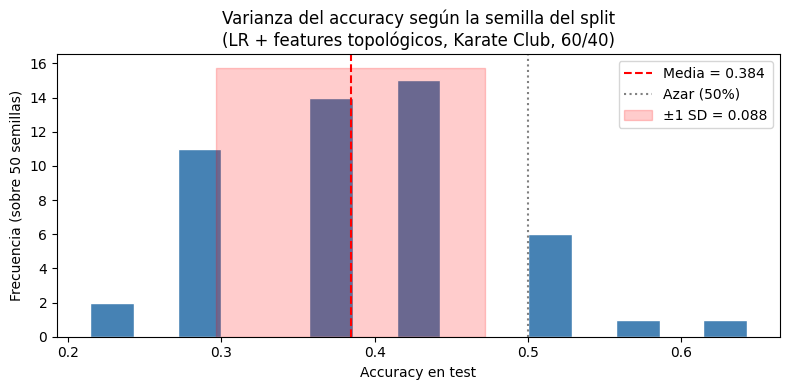

Baseline mayoría (predecir siempre clase más frecuente): 0.500
Accuracy media (50 semillas):  0.384 ± 0.088
Rango: [0.214, 0.643]
Diferencia mejor vs peor run:  0.429

Nota: la media cae DEBAJO del baseline de mayoría en algunos experimentos.
Esto refleja que con ~20 nodos de train, el split puede ser estructuralmente
muy desfavorable (mayoría de una clase en train, otra clase domina en test).


In [29]:
# ── Demostrar la varianza por semilla de split ────────────────────────────
# Con el Karate Club (muy pequeño, n=34) la varianza es extrema.
# Split: 60% train (~20 nodos), 40% test (~14 nodos).
# Repetimos 50 veces cambiando solo la semilla del shuffle.

G_kc = nx.karate_club_graph()
nodes_kc = sorted(G_kc.nodes())
labs_kc  = np.array([0 if G_kc.nodes[n]['club'] == 'Mr. Hi' else 1 for n in nodes_kc])

# Extraer features topológicos
X_kc = np.column_stack([
    [G_kc.degree(n)                        for n in nodes_kc],
    [nx.clustering(G_kc, n)                for n in nodes_kc],
    [nx.pagerank(G_kc)[n]                  for n in nodes_kc],
    [nx.betweenness_centrality(G_kc)[n]    for n in nodes_kc],
])
X_kc = StandardScaler().fit_transform(X_kc)

accs_seeds = []
N_SEEDS = 50

for seed in range(N_SEEDS):
    rng_s = np.random.default_rng(seed)
    idx = np.arange(len(nodes_kc))
    rng_s.shuffle(idx)
    cut = int(0.6 * len(idx))
    tr, te = idx[:cut], idx[cut:]
    clf = LogisticRegression(max_iter=500, random_state=seed, C=1.0)
    clf.fit(X_kc[tr], labs_kc[tr])
    accs_seeds.append(accuracy_score(labs_kc[te], clf.predict(X_kc[te])))

accs_seeds = np.array(accs_seeds)

# Guardamos el ymax después de dibujar el histograma para que fill_betweenx lo use
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(accs_seeds, bins=15, edgecolor='white', color='steelblue')
ymax = ax.get_ylim()[1]   # capturar después de hist() para que el ylim esté actualizado

ax.axvline(accs_seeds.mean(), linestyle='--', color='red',
           label=f'Media = {accs_seeds.mean():.3f}')
ax.axvline(0.5, linestyle=':', color='gray', label='Azar (50%)')
ax.fill_betweenx(
    [0, ymax],
    accs_seeds.mean() - accs_seeds.std(),
    accs_seeds.mean() + accs_seeds.std(),
    alpha=0.2, color='red', label=f'±1 SD = {accs_seeds.std():.3f}'
)
ax.set_xlabel('Accuracy en test')
ax.set_ylabel('Frecuencia (sobre 50 semillas)')
ax.set_title('Varianza del accuracy según la semilla del split\n(LR + features topológicos, Karate Club, 60/40)')
ax.legend()
plt.tight_layout()
plt.show()

majority_baseline = max(labs_kc.mean(), 1 - labs_kc.mean())
print(f'Baseline mayoría (predecir siempre clase más frecuente): {majority_baseline:.3f}')
print(f'Accuracy media (50 semillas):  {accs_seeds.mean():.3f} ± {accs_seeds.std():.3f}')
print(f'Rango: [{accs_seeds.min():.3f}, {accs_seeds.max():.3f}]')
print(f'Diferencia mejor vs peor run:  {accs_seeds.max() - accs_seeds.min():.3f}')
print()
print('Nota: la media cae DEBAJO del baseline de mayoría en algunos experimentos.')
print('Esto refleja que con ~20 nodos de train, el split puede ser estructuralmente')
print('muy desfavorable (mayoría de una clase en train, otra clase domina en test).')

#### Takeaway

En este experimento, la media de accuracy (~38%) cae **por debajo del 50% de azar** y muy por debajo del baseline de mayoría (53%). Esto no significa que el modelo sea inútil: significa que el Karate Club es demasiado pequeño para que un split 60/40 aleatorio sea estable.

Con solo ~20 nodos de train, algunos splits ponen una clase casi entera en test. El modelo aprende la distribución incorrecta y generaliza peor que adivinar. El mejor run (>60%) y el peor (<22%) corresponden al mismo modelo, mismos datos, mismos hiperparámetros —solo cambia la semilla del shuffle.

**Diferencia entre el mejor y peor run: >40 puntos de accuracy.** Eso es mayor que la diferencia entre cualquier par de GNN en los benchmarks de Shchur et al. (2018).

> **Regla:** con grafos pequeños (n < 500), los resultados de una sola semilla no son informativos. Reporta siempre media ± SD sobre ≥10 semillas, y si el grafo es muy pequeño, considera cross-validation por nodos (k-fold estructural) en lugar de un split único.

---

## 11. Poder expresivo de las GNN: el test de Weisfeiler-Lehman

### 11.1 ¿Cuán poderosas son las GNN?

Xu et al. (2019) establecieron el límite teórico del poder expresivo de las GNN de message passing:

> **Una GNN de message passing es a lo sumo tan poderosa como el test de Weisfeiler-Lehman (1-WL) para distinguir grafos.**

Esto tiene consecuencias prácticas directas.

### 11.2 El test de Weisfeiler-Lehman (WL) en 4 pasos

El test WL decide si dos grafos son (posiblemente) isomorfos refinando coloraciones iterativamente:

```
Paso 1 — Inicialización:
         Cada nodo recibe el mismo color inicial (o su etiqueta si la tiene).
         Grafo A: todos los nodos color "1"
         Grafo B: todos los nodos color "1"

Paso 2 — Refinamiento:
         Cada nodo actualiza su color combinando su color actual
         con el MULTISET de colores de sus vecinos.
         Ejemplo: nodo v con color "1" y vecinos de colores {1, 1, 2}
                  → nuevo color = hash("1", {1,1,2}) = "A"

Paso 3 — Repetir hasta convergencia o diferencia:
         Si en alguna iteración los histogramas de colores difieren
         entre los dos grafos → los grafos NO son isomorfos (distintos).
         Si convergen con los mismos histogramas → pueden ser isomorfos.

Paso 4 — Límite:
         El WL no puede distinguir grafos 3-regulares entre sí
         (dos grafos donde todos los nodos tienen exactamente grado 3
         producen los mismos histogramas de color indefinidamente).
```

**Por qué esto importa para las GNN:** message passing hace exactamente lo mismo que WL, con colores reemplazados por vectores reales y hash reemplazado por una función aprendible. La **GIN** (Xu et al., 2019) maximiza este poder usando suma (no media) como AGGREGATE y un MLP como función de combinación, siendo tan expresiva como 1-WL.

### 11.3 ¿Qué NO puede hacer ninguna GNN de message passing?

1. **Contar triángulos exactamente.** Las GNN no pueden distinguir un nodo en un triángulo de uno en un ciclo de 4, a menos que usen extensiones (SEAL, ID-GNN).
2. **Distinguir grafos 3-regulares.** Dos grafos distintos donde todos los nodos tienen grado 3 tienen el mismo WL fingerprint.
3. **Capturar estructura global.** La longitud del camino más corto entre dos nodos lejanos es invisible para GNN locales.

Para tareas que requieren estas capacidades (biología molecular, química, redes de infraestructura), se necesitan extensiones: **k-WL GNN**, **RWPE** (random walk positional encodings), o **Graph Transformers** con atención global.

### 11.4 ¿Cuándo GNN supera a métodos clásicos?

Basado en la evidencia acumulada (Errica et al., 2020; Shchur et al., 2018; Lim et al., 2021), las GNN tienen ventaja cuando:

1. **Hay features nodales informativos** que se benefician de ser propagados por la estructura.
2. **La red es homofílica** ($h > 0.5$): los vecinos son señal, no ruido.
3. **El grafo es lo suficientemente grande** (>200 nodos etiquetados como mínimo).
4. **La tarea requiere inducción**: necesitas embeddings para nodos no vistos.
5. **La estructura local importa**: triángulos, vecindarios, roles locales son predictivos.

Fuera de esas condiciones, la diferencia puede ser pequeña o incluso negativa.

---

## 12. Conectando con la clase anterior: el ecosistema completo

Todo lo visto en las 8 clases forma un ciclo metodológico:

```
┌─────────────────────────────────────────────────────────────────────────┐
│                   CICLO METODOLÓGICO EN CIENCIA DE REDES                │
│                                                                         │
│  1. REPRESENTACIÓN      ¿Qué es un nodo? ¿Qué es una arista?           │
│     (Clase 1–2)         Dirigida / ponderada / bipartita / temporal     │
│         ↓                                                               │
│  2. ESTRUCTURA LOCAL    Grado, clustering, componentes                  │
│     (Clase 1–2)                                                         │
│         ↓                                                               │
│  3. CENTRALIDADES       ¿Quién importa y para qué?                     │
│     (Clase 3)                                                           │
│         ↓                                                               │
│  4. MODELOS NULOS       ¿Lo observado es más de lo esperable?          │
│     (Clase 4)                                                           │
│         ↓                                                               │
│  5. MESOESTRUCTURA      Comunidades, bloques, particiones               │
│     (Clase 5)                                                           │
│         ↓                                                               │
│  6. DINÁMICA            Contagio, difusión, umbrales, intervención      │
│     (Clase 6)                                                           │
│         ↓                                                               │
│  7. INFERENCIA          Splits, leakage, permutation tests, ética       │
│     (Clase 7)                                                           │
│         ↓                                                               │
│  8. GRAPH ML            Features → Embeddings → GNN + evaluación        │
│     (Clase 8)                                                           │
│         ↓                                                               │
│  INDUSTRIA              ¿Cuándo tiene sentido? ¿Cómo evaluar?          │
└─────────────────────────────────────────────────────────────────────────┘
```

Las GNN no reemplazan el análisis de redes clásico: lo complementan cuando hay suficiente señal, datos y recursos.

---

## 13. Roadmap de aprendizaje

Para seguir profundizando después del curso:

### Nivel 1 — Fundamentos (ya tienes estas bases)
- **Hamilton (2020).** *Graph Representation Learning*. Synthesis Lectures. — el libro del curso.
- **Newman (2010).** *Networks: An Introduction*. Oxford. — referencia clásica de ciencia de redes.

### Nivel 2 — Implementación
- **PyTorch Geometric (PyG):** librería principal para GNN en PyTorch. Tutorial oficial: [pytorch-geometric.readthedocs.io](https://pytorch-geometric.readthedocs.io)
- **Deep Graph Library (DGL):** alternativa de AWS/NYU, compatible con PyTorch y TensorFlow.
- **Stanford OGB:** benchmarks estandarizados para comparación honesta. [ogb.stanford.edu](https://ogb.stanford.edu)

### Nivel 3 — Papers fundacionales (leer en orden)
1. Perozzi et al. (2014). **DeepWalk** — el primero en embeddings con caminatas aleatorias.
2. Grover & Leskovec (2016). **node2vec** — control BFS/DFS.
3. Kipf & Welling (2017). **GCN** — la arquitectura más citada.
4. Hamilton et al. (2017). **GraphSAGE** — inductive learning.
5. Veličković et al. (2018). **GAT** — atención en grafos.
6. Xu et al. (2019). **GIN** — poder expresivo.
7. Shchur et al. (2018). **Pitfalls** — por qué la evaluación importa.
8. Errica et al. (2020). **Fair comparison** — baselines honestos.

### Nivel 4 — Tópicos avanzados
- **Redes temporales:** EvolveGCN, TGN (Temporal Graph Network).
- **Grafos heterogéneos:** HAN, HGT.
- **Explicabilidad:** GNNExplainer, PGExplainer.
- **Over-smoothing y over-squashing:** problemas al profundizar las GNN.
- **Graph Transformers:** Graphormer, GPS.

---

## 14. Síntesis final: qué debe quedar claro

Al cerrar el curso, estas son las preguntas que deberías poder responder con claridad:

### Sobre representación
1. ¿Qué información estructural captura un feature topológico que no captura un atributo tabular?
2. ¿Cuál es la diferencia entre un embedding espectral y uno por caminatas aleatorias?
3. ¿Qué hace una GCN que no hace un MLP?

### Sobre evaluación
4. ¿Por qué un split aleatorio de nodos puede producir leakage en una GNN?
5. ¿Qué significa que el campo receptivo de 2 capas cubre el 90% de train?
6. ¿Cómo afecta el número de semillas del split a la validez de una comparación de modelos?

### Sobre decisión
7. ¿Bajo qué condiciones no tiene sentido usar una GNN?
8. ¿Qué baselines debes vencer antes de reportar una GNN como «mejor modelo»?
9. ¿Por qué la heterofilia puede hacer que message passing sea contraproducente?

### Sobre industria
10. ¿Qué aportó PinSage que no podía lograrse con recomendación estándar?
11. ¿Por qué el split temporal es crítico en detección de fraude?
12. ¿Qué hace a las moléculas un dominio natural para GNN?

---

## 15. Checklist para Graph ML en proyectos reales

Antes de desplegar cualquier modelo de Graph ML en un proyecto real, deberías poder responder afirmativamente a estas preguntas:

### Definición del problema
- [ ] ¿La tarea está bien definida (clasificación nodal, link prediction, clasificación de grafos)?
- [ ] ¿El grafo captura una relación sustantiva para esa tarea o es un proxy ruidoso?
- [ ] ¿Hay señal topológica genuina (comprobada con modelo nulo)?

### Datos y representación
- [ ] ¿Qué significa un nodo? ¿Qué significa una arista?
- [ ] ¿Hay features nodales informativos disponibles?
- [ ] ¿La red es homofílica? (si no, cuidado con GCN estándar)
- [ ] ¿Cuántos nodos etiquetados hay? (¿suficiente para una GNN?)

### Evaluación
- [ ] ¿El split es coherente con el escenario real de uso?
- [ ] ¿Se revisó el solapamiento de vecindarios entre train y test?
- [ ] ¿Se reporta media ± std sobre ≥10 semillas?
- [ ] ¿Se compara contra todos los baselines (topo features, embedding, GCN básica)?
- [ ] ¿La métrica elegida es apropiada para el desbalance de clases?

### Interpretación y ética
- [ ] ¿El claim está al nivel de la evidencia?
- [ ] ¿Hay riesgo de reidentificación o daño relacional?
- [ ] ¿La intervención derivada del modelo podría amplificar inequidades estructurales?

---

## 16. Referencias

### Libro del curso
- Hamilton, W. L. (2020). *Graph representation learning*. Synthesis Lectures on Artificial Intelligence and Machine Learning, 14(3), 1–159. https://doi.org/10.2200/S01045ED1V01Y202009AIM046

### Embeddings y caminatas aleatorias
- Perozzi, B., Al-Rfou, R., & Skiena, S. (2014). DeepWalk: Online learning of social representations. *Proceedings of KDD 2014*, 701–710. https://doi.org/10.1145/2623330.2623732
- Grover, A., & Leskovec, J. (2016). node2vec: Scalable feature learning for networks. *Proceedings of KDD 2016*, 855–864. https://doi.org/10.1145/2939672.2939754
- Tang, J., Qu, M., Wang, M., Zhang, M., Yan, J., & Mei, Q. (2015). LINE: Large-scale information network embedding. *Proceedings of WWW 2015*, 1067–1077. https://doi.org/10.1145/2736277.2741093
- Belkin, M., & Niyogi, P. (2003). Laplacian eigenmaps for dimensionality reduction and data representation. *Neural Computation*, 15(6), 1373–1396. https://doi.org/10.1162/089976603321780317
- Levy, O., & Goldberg, Y. (2014). Neural word embedding as implicit matrix factorization. *NeurIPS 2014*, 2177–2185. — muestra que skip-gram con negative sampling es equivalente a SVD sobre una matriz de PMI pointwise, que es lo que usamos con `log1p(M)`.
- Shi, J., & Malik, J. (2000). Normalized cuts and image segmentation. *IEEE TPAMI*, 22(8), 888–905. https://doi.org/10.1109/34.868688 — base teórica del vector de Fiedler para partición de grafos.

### Graph Neural Networks
- Kipf, T. N., & Welling, M. (2017). Semi-supervised classification with graph convolutional networks. *ICLR 2017*. https://arxiv.org/abs/1609.02907
- Hamilton, W. L., Ying, R., & Leskovec, J. (2017). Inductive representation learning on large graphs. *NeurIPS 2017*, 1024–1034. https://arxiv.org/abs/1706.02216
- Veličković, P., Cucurull, G., Casanova, A., Romero, A., Liò, P., & Bengio, Y. (2018). Graph attention networks. *ICLR 2018*. https://arxiv.org/abs/1710.10903
- Xu, K., Hu, W., Leskovec, J., & Jegelka, S. (2019). How powerful are graph neural networks? *ICLR 2019*. https://arxiv.org/abs/1810.00826
- Gilmer, J., Schütt, K. T., Ghahramani, Z., & Welling, M. (2017). Neural message passing for quantum chemistry. *ICML 2017*, 1263–1272. https://arxiv.org/abs/1704.01212
- Li, Q., Han, Z., & Wu, X.-M. (2018). Deeper insights into graph convolutional networks for semi-supervised classification. *AAAI 2018*. https://arxiv.org/abs/1801.07606

### Evaluación y pitfalls
- Shchur, O., Mumme, M., Bojchevski, A., & Günnemann, S. (2018). Pitfalls of graph neural network evaluation. *NeurIPS Workshop on Relational Representation Learning*. https://arxiv.org/abs/1811.05868
- Errica, F., Podda, M., Bacciu, D., & Micheli, A. (2020). A fair comparison of graph neural networks for graph classification. *ICLR 2020*. https://arxiv.org/abs/1912.09893
- Huang, B., Ioannidis, V. N., & Karypis, G. (2023). Pitfalls in link prediction with graph neural networks: Understanding the impact of target-link inclusion & better practices. https://arxiv.org/abs/2306.00899
- Hu, W., Fey, M., Zitnik, M., Dong, Y., Ren, H., Liu, B., Catasta, M., & Leskovec, J. (2020). Open graph benchmark: Datasets for machine learning on graphs. *NeurIPS 2020*. https://arxiv.org/abs/2005.00687

### Homofilia y heterofilia
- Lim, D., Li, X., Hohne, F., Kim, S. J., & Naddaf-Sh, S. (2021). Large scale learning on non-homophilous graphs: New benchmarks and strong simple methods. *NeurIPS 2021*. https://arxiv.org/abs/2110.14446

### Aplicaciones en industria
- Ying, R., He, R., Chen, K., Eksombatchai, P., Hamilton, W. L., & Leskovec, J. (2018). Graph convolutional neural networks for web-scale recommender systems. *Proceedings of KDD 2018*, 974–983. https://doi.org/10.1145/3219819.3219890
- Weber, M., Domeniconi, G., Chen, J., Weidele, D. K. I., Bellei, C., Robinson, T., & Leiserson, C. E. (2019). Anti-money laundering in Bitcoin: Experimenting with graph convolutional networks for financial forensics. *KDD Workshop on Anomaly Detection in Finance*. https://arxiv.org/abs/1908.02591
- Stokes, J. M., Yang, K., Swanson, K., Jin, W., Cubillos-Ruiz, A., Donghia, N. M., MacNair, C. R., French, S., Carfrae, L. A., Bloom-Ackermann, Z., Tran, V. M., Chiappino-Pepe, A., Badran, A. H., Andrews, I. W., Chory, E. J., Church, G. M., Brown, E. D., Jaakkola, T. S., Barzilay, R., & Collins, J. J. (2020). A deep learning approach to antibiotic discovery. *Cell*, 180(4), 688–702. https://doi.org/10.1016/j.cell.2020.01.021
- Pareja, A., Domeniconi, G., Chen, J., Ma, T., Suzumura, T., Kanezashi, H., Kaler, T., & Leiserson, C. E. (2020). EvolveGCN: Evolving graph convolutional networks for dynamic graphs. *AAAI 2020*. https://arxiv.org/abs/1902.10191
- Bordes, A., Usunier, N., Garcia-Duran, A., Weston, J., & Yakhnenko, O. (2013). Translating embeddings for modeling multi-relational data. *NeurIPS 2013*, 2787–2795. https://proceedings.neurips.cc/paper/2013/hash/1cecc7a77928ca8133fa24680a88d2f9-Abstract.html

### Base del curso
- Newman, M. E. J. (2010). *Networks: An Introduction*. Oxford University Press.
- Easley, D., & Kleinberg, J. (2010). *Networks, Crowds, and Markets*. Cambridge University Press.
- Zachary, W. W. (1977). An information flow model for conflict and fission in small groups. *Journal of Anthropological Research*, 33(4), 452–473. https://doi.org/10.1086/jar.33.4.3629752